Random Forest

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

Predicted Distribution:
[22  7]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.75      0.71        20
           1       0.29      0.22      0.25         9

    accuracy                           0.59        29
   macro avg       0.48      0.49      0.48        29
weighted avg       0.56      0.59      0.57        29

Precision Score: 0.2857
Recall Score: 0.2222
F1 Score: 0.25
ROC-AUC Score: 0.6028

Confusion Matrix:
[[15  5]
 [ 7  2]]


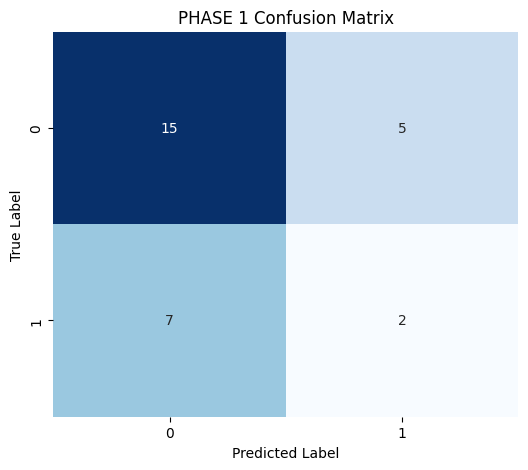


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

Predicted Distribution:
[21  8]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        20
           1       0.38      0.33      0.35         9

    accuracy                           0.62        29
   macro avg       0.54      0.54      0.54        29
weighted avg       0.61      0.62      0.61        29

Precision Score: 0.375
Recall Score: 0.3333
F1 Score: 0.3529
ROC-AUC Score: 0.4556

Confusion Matrix:
[[15  5]
 [ 6  3]]


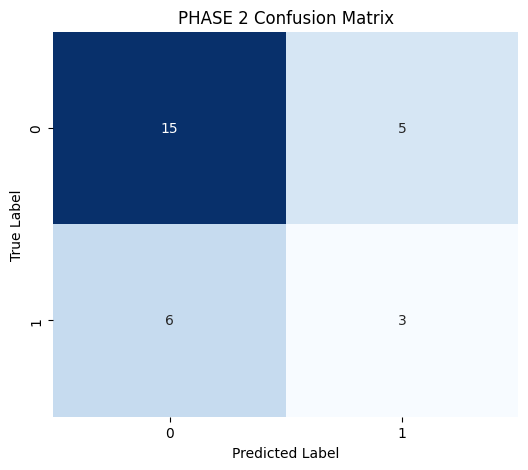


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

Predicted Distribution:
[24  5]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.85      0.77        20
           1       0.40      0.22      0.29         9

    accuracy                           0.66        29
   macro avg       0.55      0.54      0.53        29
weighted avg       0.61      0.66      0.62        29

Precision Score: 0.4
Recall Score: 0.2222
F1 Score: 0.2857
ROC-AUC Score: 0.4333

Confusion Matrix:
[[17  3]
 [ 7  2]]


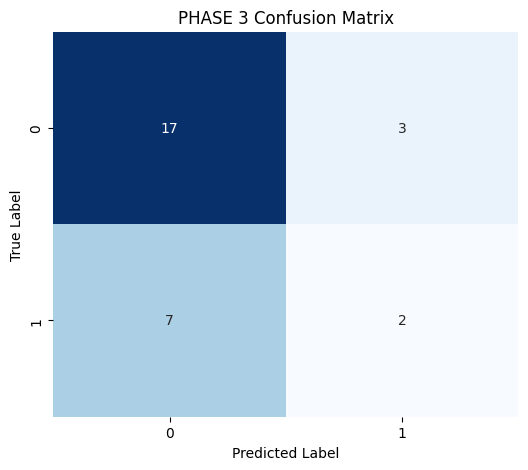


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6028
Phase 1 Precision: 0.2857
Phase 1 Recall: 0.2222
Phase 1 F1 Score: 0.2500

Phase 2 ROC-AUC: 0.4556
Phase 2 Precision: 0.3750
Phase 2 Recall: 0.3333
Phase 2 F1 Score: 0.3529

Phase 3 ROC-AUC: 0.4333
Phase 3 Precision: 0.4000
Phase 3 Recall: 0.2222
Phase 3 F1 Score: 0.2857


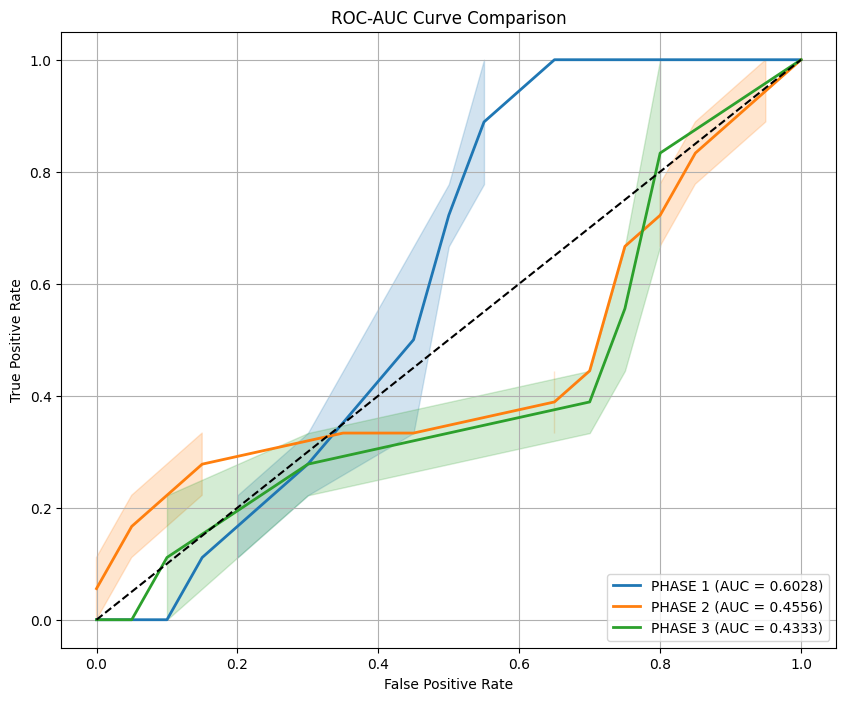

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # keep numeric columns only
    df_phase = df_phase.select_dtypes(
        include=["int64", "float64"]
    )

    # drop missing values
    df_phase = df_phase.dropna()

    # features and labels
    X = df_phase.drop("label", axis=1).values
    y = df_phase["label"].values

    print("Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # feature scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # random forest model
    model = RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # predictions
    THRESHOLD = 0.40

    y_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y_test, y_pred)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y_test, y_pred)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y_test, y_pred)

    print("F1 Score:", round(f1, 4))

    # roc auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter phase-wise data
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Random Forest 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.6278

----- Fold 2 -----
Fold ROC-AUC: 0.8094

----- Fold 3 -----
Fold ROC-AUC: 0.6531

----- Fold 4 -----
Fold ROC-AUC: 0.7188

----- Fold 5 -----
Fold ROC-AUC: 0.6579

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6278 0.8094 0.6531 0.7188 0.6579]

Mean Fold ROC-AUC:
0.6934

Overall ROC-AUC:
0.6762

Classification Report:
              precision    recall  f1-score   

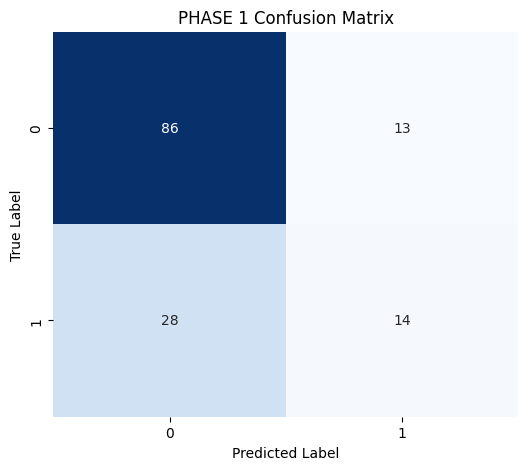


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.6194

----- Fold 2 -----
Fold ROC-AUC: 0.575

----- Fold 3 -----
Fold ROC-AUC: 0.6187

----- Fold 4 -----
Fold ROC-AUC: 0.6219

----- Fold 5 -----
Fold ROC-AUC: 0.7193

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6194 0.575  0.6187 0.6219 0.7193]

Mean Fold ROC-AUC:
0.6309

Overall ROC-AUC:
0.6098

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.78        99
           1       0.45      0.33      0.38        42

    accuracy                           0.68       141
   macro avg       0.60      0.58      0.58       141
weighted avg       0.66      0.68      0.67       

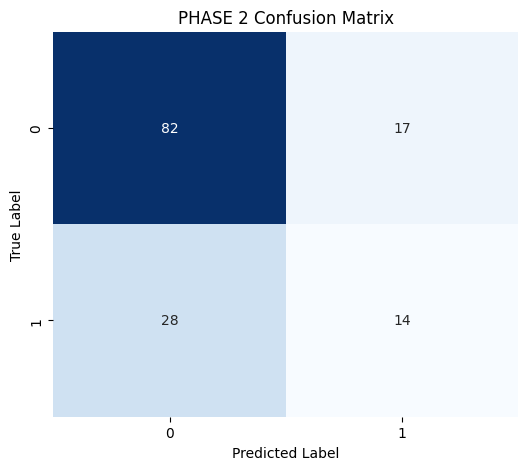


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.6167

----- Fold 2 -----
Fold ROC-AUC: 0.7875

----- Fold 3 -----
Fold ROC-AUC: 0.6656

----- Fold 4 -----
Fold ROC-AUC: 0.55

----- Fold 5 -----
Fold ROC-AUC: 0.6404

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6167 0.7875 0.6656 0.55   0.6404]

Mean Fold ROC-AUC:
0.652

Overall ROC-AUC:
0.6338

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.78        99
           1       0.45      0.33      0.38        42

    accuracy                           0.68       141
   macro avg       0.60      0.58      0.58       141
weighted avg       0.66      0.68      0.67       14

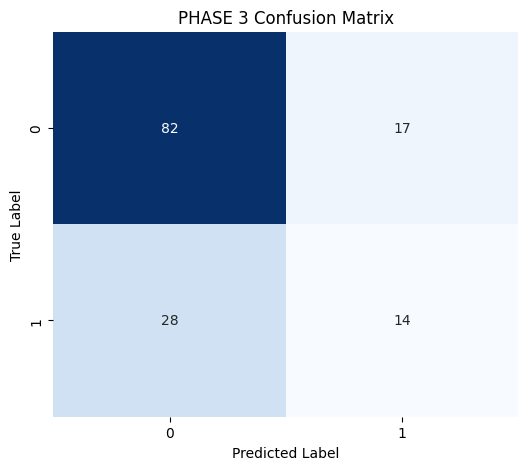


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6762
Phase 1 Precision: 0.5185
Phase 1 Recall: 0.3333
Phase 1 F1 Score: 0.4058

Phase 2 ROC-AUC: 0.6098
Phase 2 Precision: 0.4516
Phase 2 Recall: 0.3333
Phase 2 F1 Score: 0.3836

Phase 3 ROC-AUC: 0.6338
Phase 3 Precision: 0.4516
Phase 3 Recall: 0.3333
Phase 3 F1 Score: 0.3836


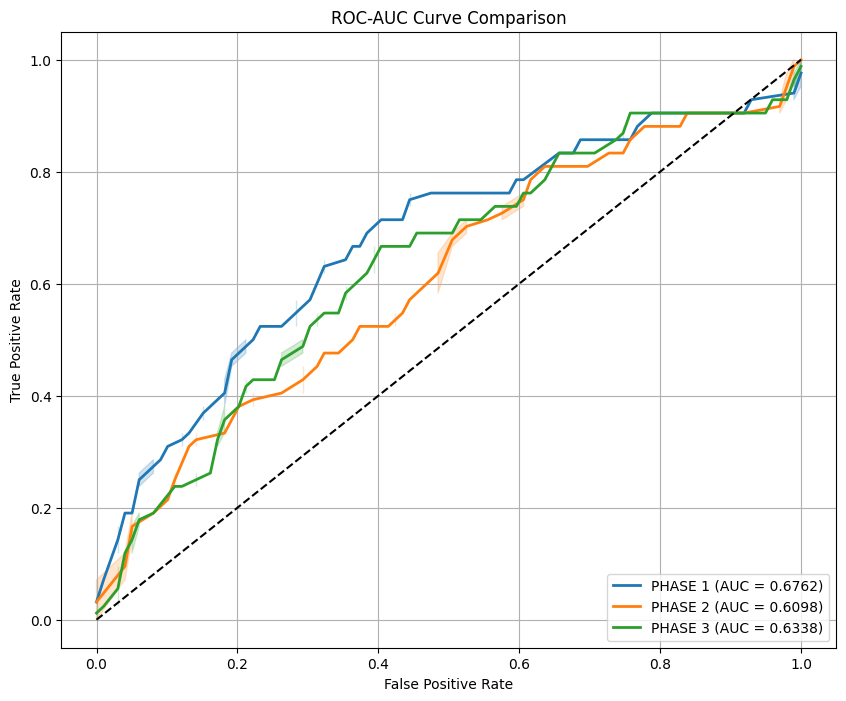

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function (5-fold rf)
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # keep numeric columns only
    df_phase = df_phase.select_dtypes(
        include=["int64", "float64"]
    )

    # drop missing values
    df_phase = df_phase.dropna()

    # features and labels
    X = df_phase.drop("label", axis=1).values
    y = df_phase["label"].values

    print("Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # random forest model
        model = RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        THRESHOLD = 0.40

        y_prob = model.predict_proba(X_test)[:, 1]

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y, all_preds)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y, all_preds)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y, all_preds)

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter phase-wise data
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Random Forest 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.64

----- Fold 2 -----
Fold ROC-AUC: 0.5

----- Fold 3 -----
Fold ROC-AUC: 0.6625

----- Fold 4 -----
Fold ROC-AUC: 0.8

----- Fold 5 -----
Fold ROC-AUC: 0.7875

----- Fold 6 -----
Fold ROC-AUC: 0.65

----- Fold 7 -----
Fold ROC-AUC: 0.6875

----- Fold 8 -----
Fold ROC-AUC: 0.7875

----- Fold 9 -----
Fold ROC-AUC: 0.7

----- Fold 10 -----
Fold ROC-AUC: 0.5556

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
-------------------------------------------------

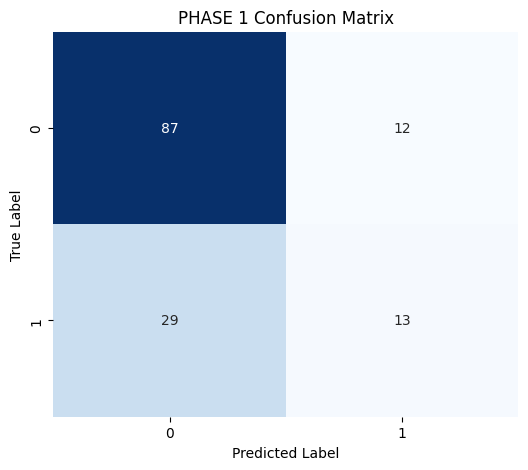


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.64

----- Fold 2 -----
Fold ROC-AUC: 0.4375

----- Fold 3 -----
Fold ROC-AUC: 0.425

----- Fold 4 -----
Fold ROC-AUC: 0.775

----- Fold 5 -----
Fold ROC-AUC: 0.75

----- Fold 6 -----
Fold ROC-AUC: 0.275

----- Fold 7 -----
Fold ROC-AUC: 0.625

----- Fold 8 -----
Fold ROC-AUC: 0.7625

----- Fold 9 -----
Fold ROC-AUC: 0.475

----- Fold 10 -----
Fold ROC-AUC: 0.8444

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.64   0.4375 0.425  0.775  0.75   0.275  0.625  0.7625 0.475  0.8444]

Mean Fold ROC-AUC:
0.6009

Overall ROC-AUC:
0.6037

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.85 

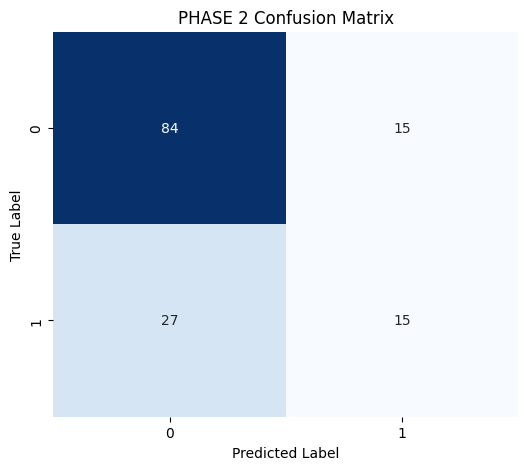


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.65

----- Fold 2 -----
Fold ROC-AUC: 0.4375

----- Fold 3 -----
Fold ROC-AUC: 0.575

----- Fold 4 -----
Fold ROC-AUC: 0.825

----- Fold 5 -----
Fold ROC-AUC: 0.75

----- Fold 6 -----
Fold ROC-AUC: 0.625

----- Fold 7 -----
Fold ROC-AUC: 0.625

----- Fold 8 -----
Fold ROC-AUC: 0.7375

----- Fold 9 -----
Fold ROC-AUC: 0.375

----- Fold 10 -----
Fold ROC-AUC: 0.7444

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.65   0.4375 0.575  0.825  0.75   0.625  0.625  0.7375 0.375  0.7444]

Mean Fold ROC-AUC:
0.6344

Overall ROC-AUC:
0.6184

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.84 

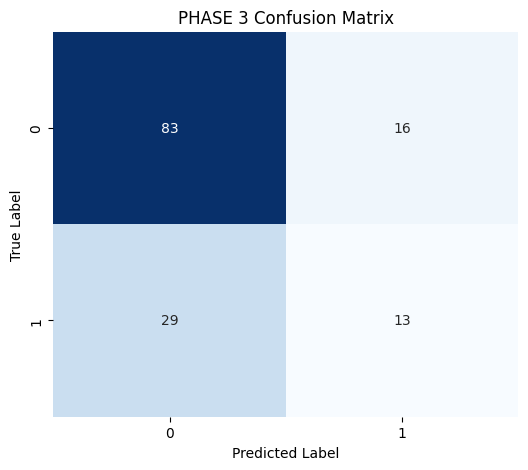


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6751
Phase 1 Precision: 0.5200
Phase 1 Recall: 0.3095
Phase 1 F1 Score: 0.3881

Phase 2 ROC-AUC: 0.6037
Phase 2 Precision: 0.5000
Phase 2 Recall: 0.3571
Phase 2 F1 Score: 0.4167

Phase 3 ROC-AUC: 0.6184
Phase 3 Precision: 0.4483
Phase 3 Recall: 0.3095
Phase 3 F1 Score: 0.3662


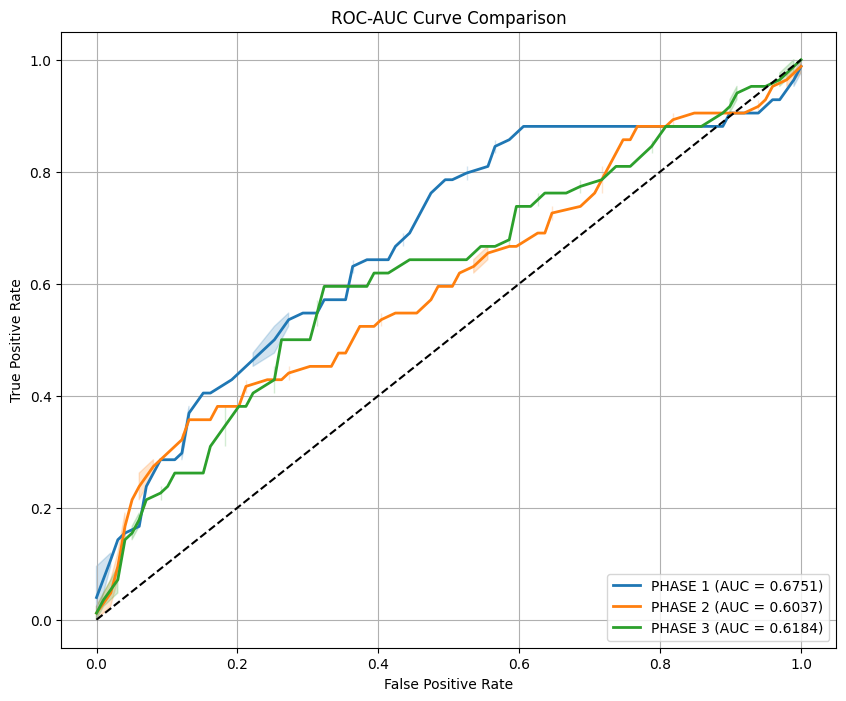

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function (5-fold rf)
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # keep numeric columns only
    df_phase = df_phase.select_dtypes(
        include=["int64", "float64"]
    )

    # drop missing values
    df_phase = df_phase.dropna()

    # features and labels
    X = df_phase.drop("label", axis=1).values
    y = df_phase["label"].values

    print("Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # random forest model
        model = RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        THRESHOLD = 0.40

        y_prob = model.predict_proba(X_test)[:, 1]

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y, all_preds)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y, all_preds)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y, all_preds)

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter phase-wise data
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

XGBoost

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 114)
Shape After SelectKBest: (141, 80)
Scale Pos Weight: 2.39

Predicted Distribution:
[12 17]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.45      0.56        20
           1       0.35      0.67      0.46         9

    accuracy                           0.52        29
   macro avg       0.55      0.56      0.51        29
weighted avg       0.63      0.52      0.53        29

Precision 

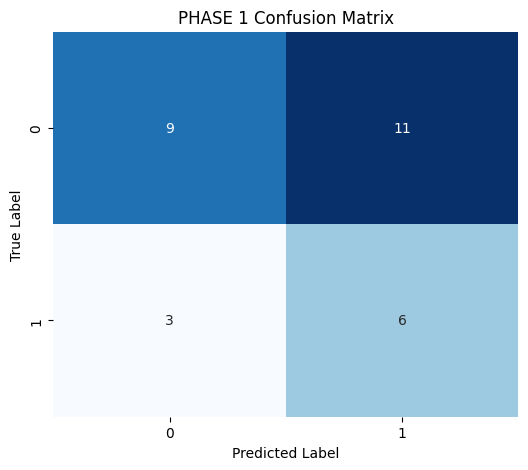


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 115)
Shape After SelectKBest: (141, 80)
Scale Pos Weight: 2.39

Predicted Distribution:
[12 17]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.35      0.44        20
           1       0.24      0.44      0.31         9

    accuracy                           0.38        29
   macro avg       0.41      0.40      0.37        29
weighted avg       0.48      0.38      0.40        29

Precision Score: 0.2353
Recall Score: 0.4444
F1 Score: 0.3077
ROC-AUC Score: 0.4056

Confusion Matrix:
[[ 7 13]
 [ 5  4]]


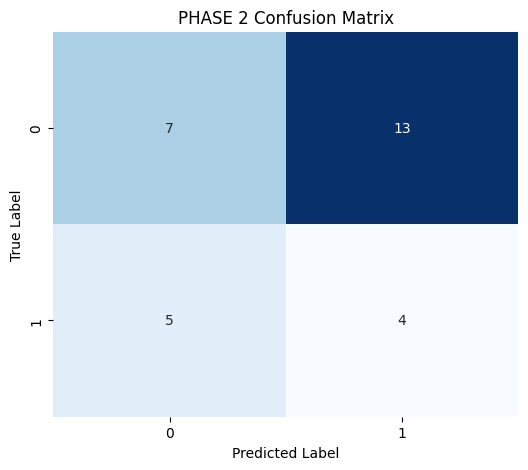


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 115)
Shape After SelectKBest: (141, 80)
Scale Pos Weight: 2.39

Predicted Distribution:
[15 14]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.45      0.51        20
           1       0.21      0.33      0.26         9

    accuracy                           0.41        29
   macro avg       0.41      0.39      0.39        29
weighted avg       0.48      0.41      0.44        29

Precision Score: 0.2143
Recall Score: 0.3333
F1 Score: 0.2609
ROC-AUC Score: 0.4278

Confusion Matrix:
[[ 9 11]
 [ 6  3]]


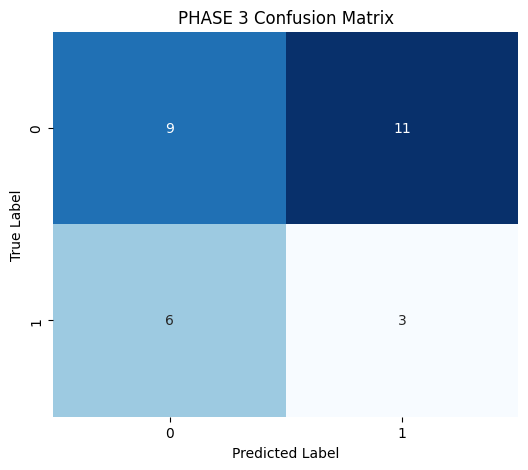


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.5111
Phase 1 Precision: 0.3529
Phase 1 Recall: 0.6667
Phase 1 F1 Score: 0.4615

Phase 2 ROC-AUC: 0.4056
Phase 2 Precision: 0.2353
Phase 2 Recall: 0.4444
Phase 2 F1 Score: 0.3077

Phase 3 ROC-AUC: 0.4278
Phase 3 Precision: 0.2143
Phase 3 Recall: 0.3333
Phase 3 F1 Score: 0.2609


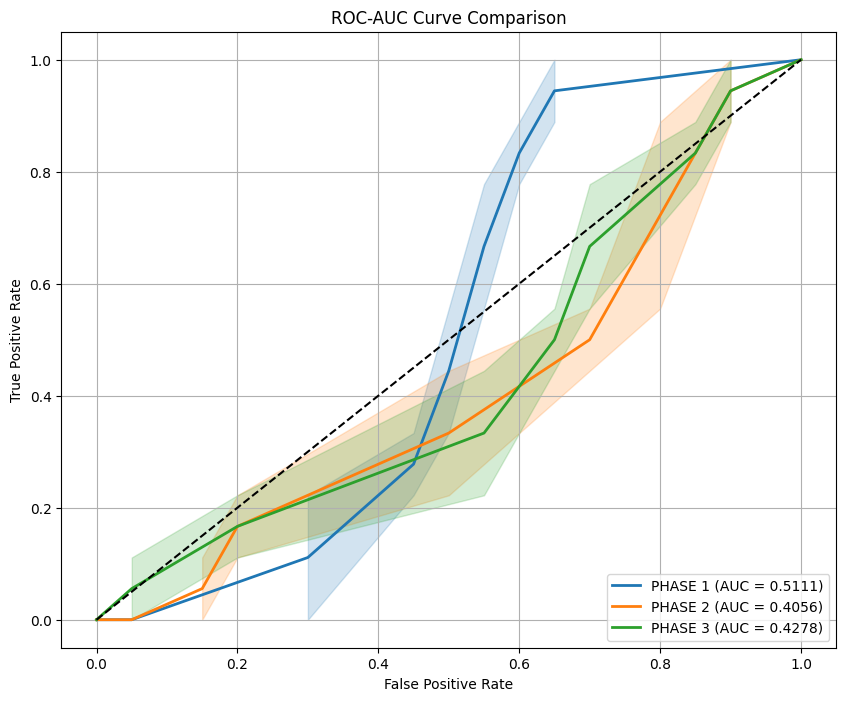

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from xgboost import XGBClassifier

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    c for c in df.columns
    if c not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # keep only numeric
    df_phase = df_phase.select_dtypes(
        include=["int64", "float64"]
    )

    # features & labels
    X = df_phase.drop("label", axis=1)
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # handle missing values
    imputer = SimpleImputer(strategy="median")

    X = imputer.fit_transform(X)

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.0001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select best features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(80, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # handle class imbalance
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)

    scale_pos_weight = neg / pos

    print("Scale Pos Weight:", round(scale_pos_weight, 2))

    # tuned xgboost model
    model = XGBClassifier(

        # core
        objective="binary:logistic",
        eval_metric="auc",

        # trees
        n_estimators=400,
        max_depth=4,

        # learning
        learning_rate=0.03,

        # sampling
        subsample=0.8,
        colsample_bytree=0.7,

        # regularization
        gamma=1,
        min_child_weight=3,

        reg_alpha=1,
        reg_lambda=3,

        # imbalance handling
        scale_pos_weight=scale_pos_weight,

        # faster optimized training
        tree_method="hist",

        random_state=42,
        n_jobs=-1
    )

    # train model
    model.fit(X_train, y_train)

    # predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold
    THRESHOLD = 0.30

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y_test, y_pred)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y_test, y_pred)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y_test, y_pred)

    print("F1 Score:", round(f1, 4))

    # roc-auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter phase-wise data
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

XGBoost 5 Folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 107)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.6222

----- Fold 2 -----
Fold ROC-AUC: 0.7125

----- Fold 3 -----
Fold ROC-AUC: 0.6562

----- Fold 4 -----
Fold ROC-AUC: 0.75

----- Fold 5 -----
Fold ROC-AUC: 0.6725

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6222 0.7125 0.6562 0.75   0.6725]

Mean Fold ROC-AUC:
0.6827

Overall ROC-AUC:
0.66

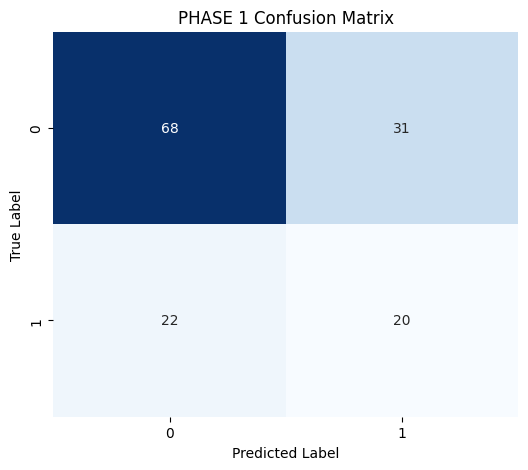


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 108)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.5611

----- Fold 2 -----
Fold ROC-AUC: 0.4625

----- Fold 3 -----
Fold ROC-AUC: 0.5125

----- Fold 4 -----
Fold ROC-AUC: 0.5562

----- Fold 5 -----
Fold ROC-AUC: 0.7018

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5611 0.4625 0.5125 0.5562 0.7018]

Mean Fold ROC-AUC:
0.5588

Overall ROC-AUC:
0.5553

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.65      0.68        99
           1       0.31      0.38      0.34        42

    accuracy                           0.57       141
   macro avg       0.51     

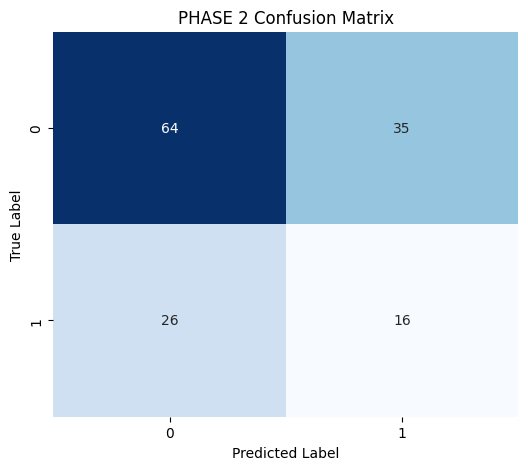


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 107)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.5833

----- Fold 2 -----
Fold ROC-AUC: 0.4062

----- Fold 3 -----
Fold ROC-AUC: 0.7188

----- Fold 4 -----
Fold ROC-AUC: 0.6062

----- Fold 5 -----
Fold ROC-AUC: 0.6608

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5833 0.4062 0.7188 0.6062 0.6608]

Mean Fold ROC-AUC:
0.5951

Overall ROC-AUC:
0.582

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72        99
           1       0.39      0.48      0.43        42

    accuracy                           0.62       141
   macro avg       0.57      

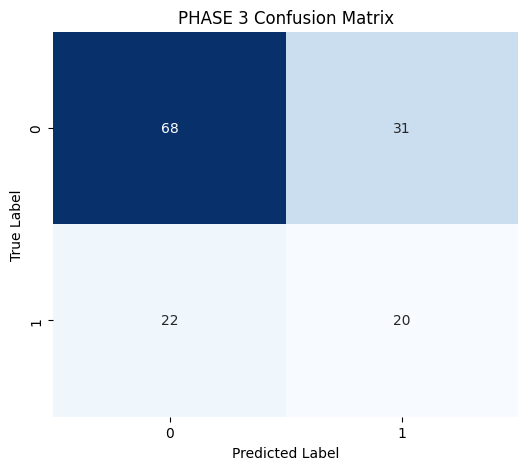


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6681
Phase 1 Precision: 0.3922
Phase 1 Recall: 0.4762
Phase 1 F1 Score: 0.4301

Phase 2 ROC-AUC: 0.5553
Phase 2 Precision: 0.3137
Phase 2 Recall: 0.3810
Phase 2 F1 Score: 0.3441

Phase 3 ROC-AUC: 0.5820
Phase 3 Precision: 0.3922
Phase 3 Recall: 0.4762
Phase 3 F1 Score: 0.4301


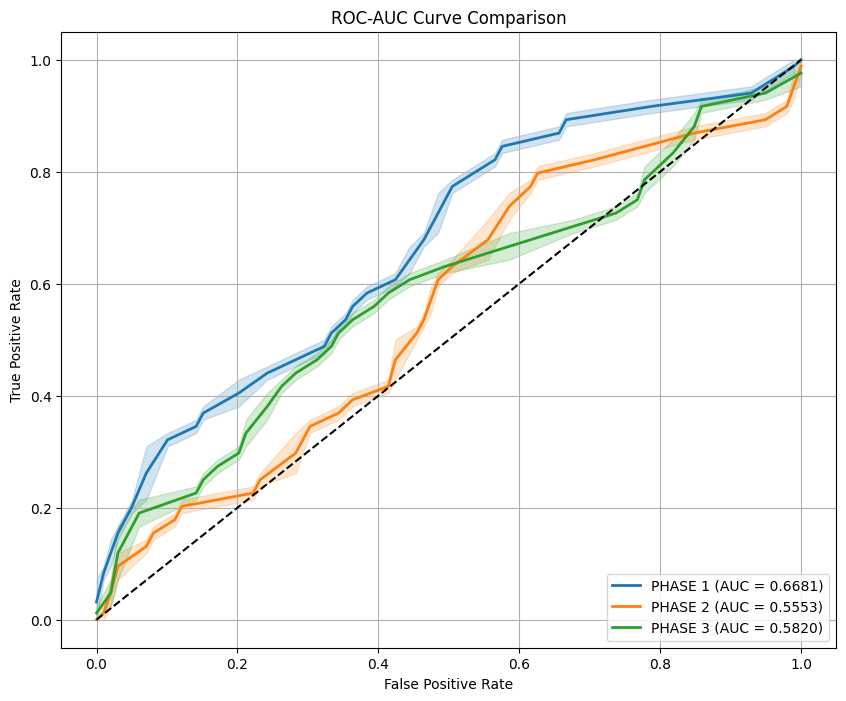

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from xgboost import XGBClassifier

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # keep numeric only
    df_phase = df_phase.select_dtypes(
        include=["int64", "float64"]
    )

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase.drop("label", axis=1)
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    selector = VarianceThreshold(
        threshold=0.001
    )

    X = selector.fit_transform(X)

    print("Shape After Variance Threshold:", X.shape)

    # handle class imbalance
    neg = np.sum(y == 0)
    pos = np.sum(y == 1)

    scale_pos_weight = neg / pos

    print("Scale Pos Weight:", round(scale_pos_weight, 2))

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # xgboost model
        model = XGBClassifier(

            objective="binary:logistic",
            eval_metric="auc",

            # trees
            n_estimators=300,
            max_depth=4,

            # learning
            learning_rate=0.03,

            # sampling
            subsample=0.8,
            colsample_bytree=0.7,

            # regularization
            gamma=1,
            min_child_weight=3,

            # imbalance handling
            scale_pos_weight=scale_pos_weight,

            # misc
            random_state=42,
            n_jobs=-1
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.40

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y, all_preds)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y, all_preds)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y, all_preds)

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter phase-wise data
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

XGBoost 10 Folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 107)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.74

----- Fold 2 -----
Fold ROC-AUC: 0.45

----- Fold 3 -----
Fold ROC-AUC: 0.7

----- Fold 4 -----
Fold ROC-AUC: 0.7

----- Fold 5 -----
Fold ROC-AUC: 0.8

----- Fold 6 -----
Fold ROC-AUC: 0.75

----- Fold 7 -----
Fold ROC-AUC: 0.825

----- Fold 8 -----
Fold ROC-AUC: 0.7

----- Fold 9 -----
Fold ROC-AUC: 0.6

----- Fold 10 -----
Fold ROC-AUC: 0.6444

------------------------------------------------------------
FINAL RES

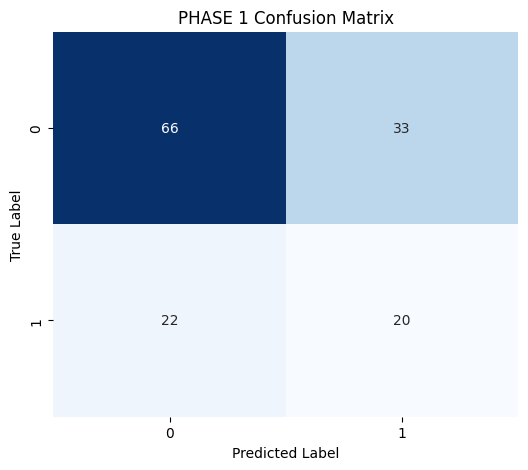


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 108)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.66

----- Fold 2 -----
Fold ROC-AUC: 0.25

----- Fold 3 -----
Fold ROC-AUC: 0.375

----- Fold 4 -----
Fold ROC-AUC: 0.6

----- Fold 5 -----
Fold ROC-AUC: 0.65

----- Fold 6 -----
Fold ROC-AUC: 0.4

----- Fold 7 -----
Fold ROC-AUC: 0.6

----- Fold 8 -----
Fold ROC-AUC: 0.725

----- Fold 9 -----
Fold ROC-AUC: 0.575

----- Fold 10 -----
Fold ROC-AUC: 0.7556

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.66   0.25   0.375  0.6    0.65   0.4    0.6    0.725  0.575  0.7556]

Mean Fold ROC-AUC:
0.5591

Overall ROC-AUC:
0.5568

Classification Report:
              precision

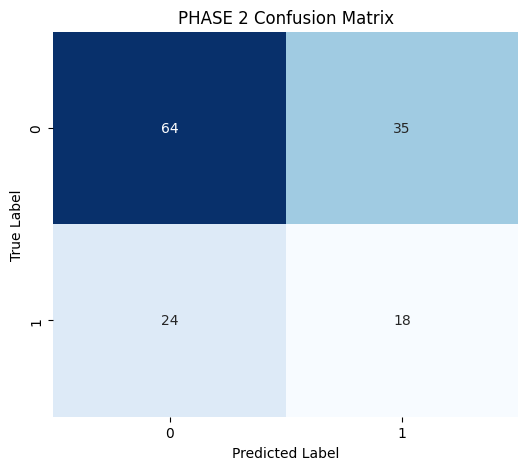


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 107)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.7

----- Fold 2 -----
Fold ROC-AUC: 0.45

----- Fold 3 -----
Fold ROC-AUC: 0.45

----- Fold 4 -----
Fold ROC-AUC: 0.625

----- Fold 5 -----
Fold ROC-AUC: 0.8

----- Fold 6 -----
Fold ROC-AUC: 0.85

----- Fold 7 -----
Fold ROC-AUC: 0.675

----- Fold 8 -----
Fold ROC-AUC: 0.65

----- Fold 9 -----
Fold ROC-AUC: 0.325

----- Fold 10 -----
Fold ROC-AUC: 0.7778

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7    0.45   0.45   0.625  0.8    0.85   0.675  0.65   0.325  0.7778]

Mean Fold ROC-AUC:
0.6303

Overall ROC-AUC:
0.6116

Classification Report:
              precisio

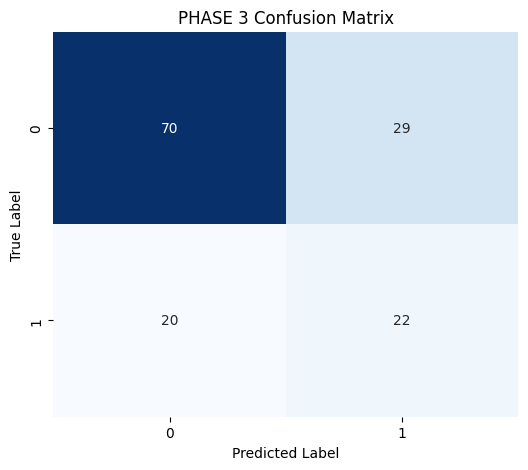


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6631
Phase 1 Precision: 0.3774
Phase 1 Recall: 0.4762
Phase 1 F1 Score: 0.4211

Phase 2 ROC-AUC: 0.5568
Phase 2 Precision: 0.3396
Phase 2 Recall: 0.4286
Phase 2 F1 Score: 0.3789

Phase 3 ROC-AUC: 0.6116
Phase 3 Precision: 0.4314
Phase 3 Recall: 0.5238
Phase 3 F1 Score: 0.4731


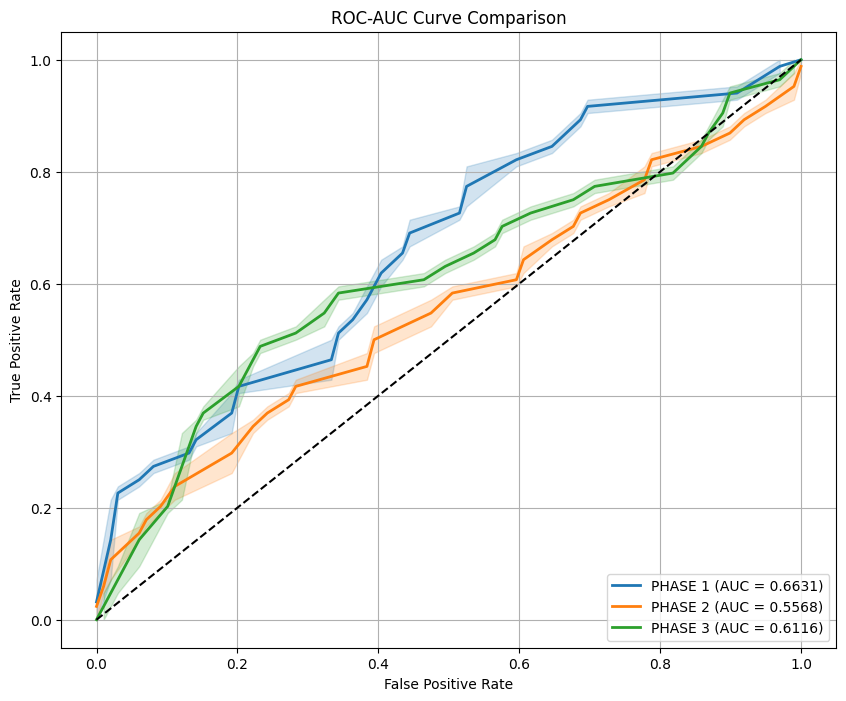

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from xgboost import XGBClassifier

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # keep numeric only
    df_phase = df_phase.select_dtypes(
        include=["int64", "float64"]
    )

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase.drop("label", axis=1)
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    selector = VarianceThreshold(
        threshold=0.001
    )

    X = selector.fit_transform(X)

    print("Shape After Variance Threshold:", X.shape)

    # handle class imbalance
    neg = np.sum(y == 0)
    pos = np.sum(y == 1)

    scale_pos_weight = neg / pos

    print("Scale Pos Weight:", round(scale_pos_weight, 2))

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # xgboost model
        model = XGBClassifier(

            objective="binary:logistic",
            eval_metric="auc",

            # trees
            n_estimators=300,
            max_depth=4,

            # learning
            learning_rate=0.03,

            # sampling
            subsample=0.8,
            colsample_bytree=0.7,

            # regularization
            gamma=1,
            min_child_weight=3,

            # imbalance handling
            scale_pos_weight=scale_pos_weight,

            # misc
            random_state=42,
            n_jobs=-1
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.40

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y, all_preds)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y, all_preds)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y, all_preds)

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter phase-wise data
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

SVM

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

Predicted Distribution:
[25  4]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.85      0.76        20
           1       0.25      0.11      0.15         9

    accuracy                           0.62        29
   macro avg       0.47      0.48      0.45        29
weighted avg       0.55      0.62      0.57        29

Precision Score: 0.25
Recall Score: 0.1111
F1 Score: 0.1538
ROC-AUC Score: 0.5444

Confusion Matrix:
[[17  3]
 [ 8  1]]


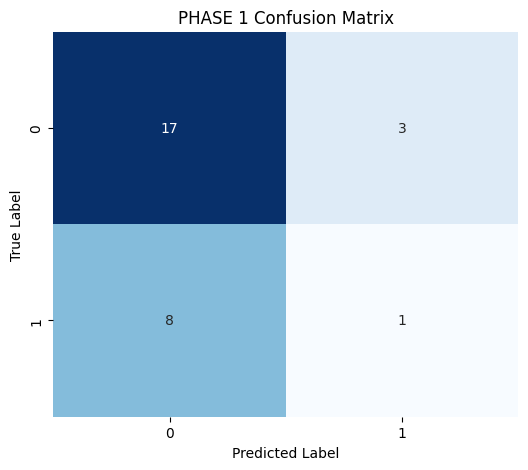


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

Predicted Distribution:
[29]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      1.00      0.82        20
           1       0.00      0.00      0.00         9

    accuracy                           0.69        29
   macro avg       0.34      0.50      0.41        29
weighted avg       0.48      0.69      0.56        29

Precision Score: 0.0
Recall Score: 0.0
F1 Score: 0.0
ROC-AUC Score: 0.4611

Confusion Matrix:
[[20  0]
 [ 9  0]]


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


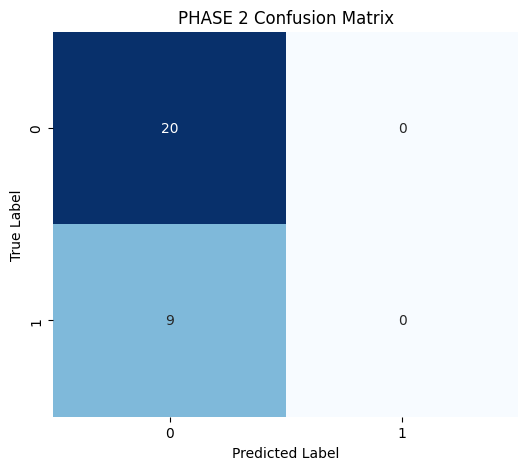


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Shape: (141, 132)
Class Distribution: [99 42]

Predicted Distribution:
[25  4]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.85      0.76        20
           1       0.25      0.11      0.15         9

    accuracy                           0.62        29
   macro avg       0.47      0.48      0.45        29
weighted avg       0.55      0.62      0.57        29

Precision Score: 0.25
Recall Score: 0.1111
F1 Score: 0.1538
ROC-AUC Score: 0.4222

Confusion Matrix:
[[17  3]
 [ 8  1]]


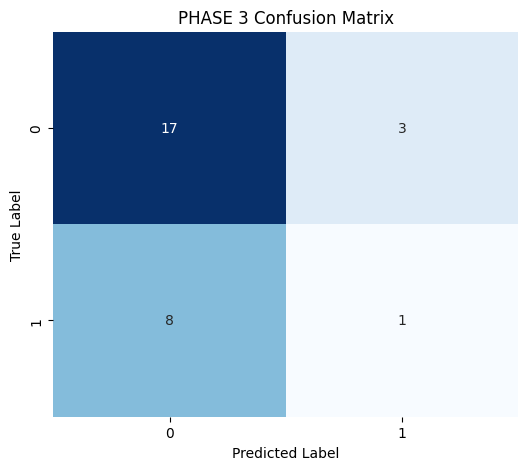


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.5444
Phase 1 Precision: 0.2500
Phase 1 Recall: 0.1111
Phase 1 F1 Score: 0.1538

Phase 2 ROC-AUC: 0.4611
Phase 2 Precision: 0.0000
Phase 2 Recall: 0.0000
Phase 2 F1 Score: 0.0000

Phase 3 ROC-AUC: 0.4222
Phase 3 Precision: 0.2500
Phase 3 Recall: 0.1111
Phase 3 F1 Score: 0.1538


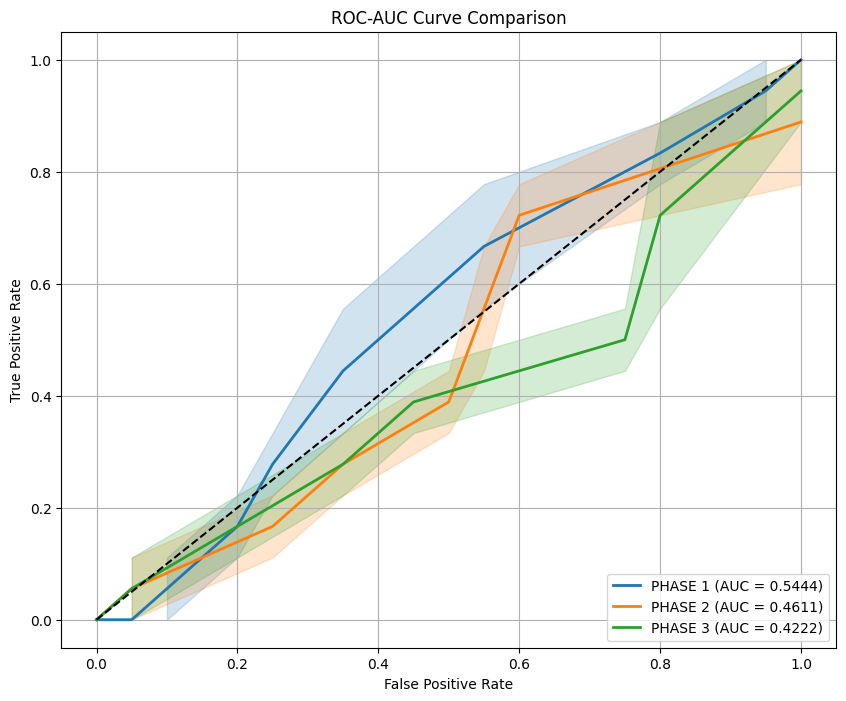

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # keep numeric columns only
    df_phase = df_phase.select_dtypes(
        include=["int64", "float64"]
    )

    # drop missing values
    df_phase = df_phase.dropna()

    # features and labels
    X = df_phase.drop("label", axis=1).values
    y = df_phase["label"].values

    print("Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # feature scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # svm model
    model = SVC(

        # rbf kernel
        kernel="rbf",

        # needed for roc-auc
        probability=True,

        # handle imbalance
        class_weight="balanced",

        # tuned parameters
        C=2,

        gamma="scale",

        random_state=42
    )

    # train model
    model.fit(X_train, y_train)

    # predict
    THRESHOLD = 0.40

    y_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y_test, y_pred)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y_test, y_pred)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y_test, y_pred)

    print("F1 Score:", round(f1, 4))

    # roc-auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter phase-wise data
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

SVM 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 105)

----- Fold 1 -----
Fold ROC-AUC: 0.5722

----- Fold 2 -----
Fold ROC-AUC: 0.675

----- Fold 3 -----
Fold ROC-AUC: 0.6813

----- Fold 4 -----
Fold ROC-AUC: 0.7437

----- Fold 5 -----
Fold ROC-AUC: 0.6959

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5722 0.675  0.6812 0.7437 0.6959]

Mean Fold ROC-AUC:
0.6736

Overall ROC-AUC:
0.67

Classification Repor

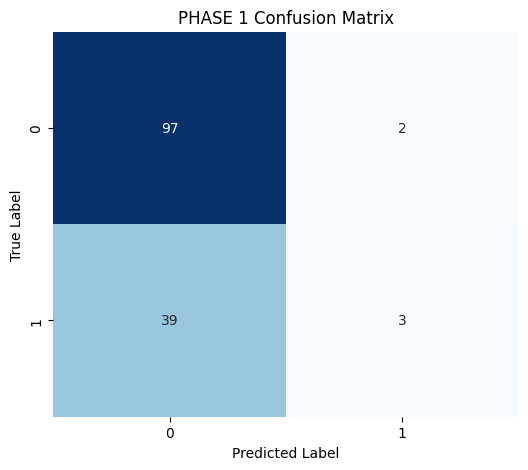


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 106)

----- Fold 1 -----
Fold ROC-AUC: 0.5556

----- Fold 2 -----
Fold ROC-AUC: 0.5875

----- Fold 3 -----
Fold ROC-AUC: 0.6

----- Fold 4 -----
Fold ROC-AUC: 0.6562

----- Fold 5 -----
Fold ROC-AUC: 0.2515

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5556 0.5875 0.6    0.6562 0.2515]

Mean Fold ROC-AUC:
0.5302

Overall ROC-AUC:
0.583

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.99      0.82        99
           1       0.50      0.02      0.05        42

    accuracy                           0.70       141
   macro avg       0.60      0.51      0.43       141
w

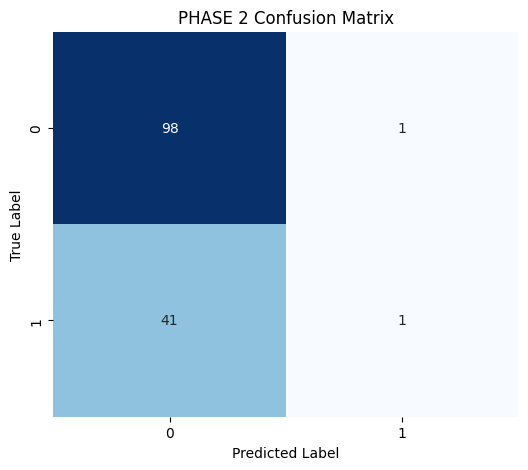


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 106)

----- Fold 1 -----
Fold ROC-AUC: 0.5444

----- Fold 2 -----
Fold ROC-AUC: 0.575

----- Fold 3 -----
Fold ROC-AUC: 0.6937

----- Fold 4 -----
Fold ROC-AUC: 0.6375

----- Fold 5 -----
Fold ROC-AUC: 0.5789

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5444 0.575  0.6938 0.6375 0.5789]

Mean Fold ROC-AUC:
0.6059

Overall ROC-AUC:
0.6217

Classification Report:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82        99
           1       0.00      0.00      0.00        42

    accuracy                           0.70       141
   macro avg       0.35      0.50      0.41       14

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


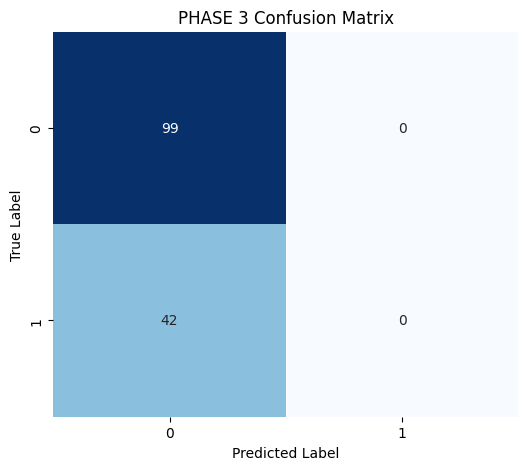


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6700
Phase 1 Precision: 0.6000
Phase 1 Recall: 0.0714
Phase 1 F1 Score: 0.1277

Phase 2 ROC-AUC: 0.5830
Phase 2 Precision: 0.5000
Phase 2 Recall: 0.0238
Phase 2 F1 Score: 0.0455

Phase 3 ROC-AUC: 0.6217
Phase 3 Precision: 0.0000
Phase 3 Recall: 0.0000
Phase 3 F1 Score: 0.0000


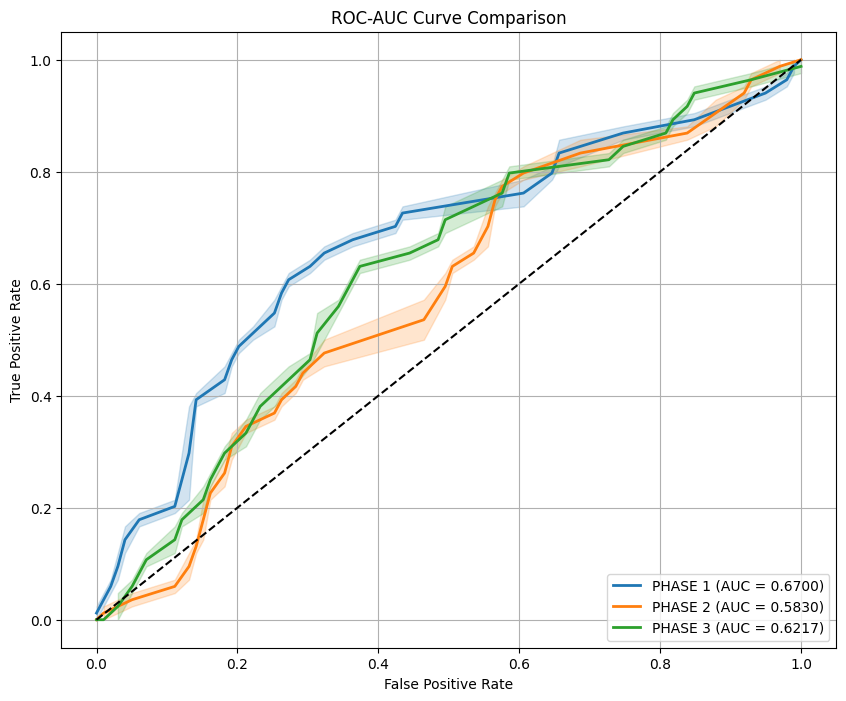

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # keep numeric only
    df_phase = df_phase.select_dtypes(
        include=["int64", "float64"]
    )

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase.drop("label", axis=1)
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    selector = VarianceThreshold(
        threshold=0.002
    )

    X = selector.fit_transform(X)

    print("Shape After Variance Threshold:", X.shape)

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # tuned svm model
        model = SVC(

            # nonlinear separation
            kernel="rbf",

            # needed for roc-auc
            probability=True,

            # handle imbalance
            class_weight="balanced",

            # stronger fitting
            C=3,

            # smoother boundary
            gamma=0.0005,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        THRESHOLD = 0.40

        y_prob = model.predict_proba(X_test)[:, 1]

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y, all_preds)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y, all_preds)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y, all_preds)

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter phase-wise data
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

SVM 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 105)

----- Fold 1 -----
Fold ROC-AUC: 0.62

----- Fold 2 -----
Fold ROC-AUC: 0.5

----- Fold 3 -----
Fold ROC-AUC: 0.65

----- Fold 4 -----
Fold ROC-AUC: 0.7

----- Fold 5 -----
Fold ROC-AUC: 0.15

----- Fold 6 -----
Fold ROC-AUC: 0.675

----- Fold 7 -----
Fold ROC-AUC: 0.725

----- Fold 8 -----
Fold ROC-AUC: 0.725

----- Fold 9 -----
Fold ROC-AUC: 0.525

----- Fold 10 -----
Fold ROC-AUC: 0.5778

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1


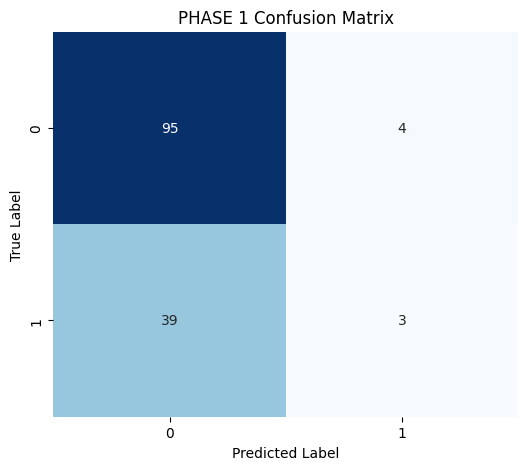


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 106)

----- Fold 1 -----
Fold ROC-AUC: 0.58

----- Fold 2 -----
Fold ROC-AUC: 0.5

----- Fold 3 -----
Fold ROC-AUC: 0.425

----- Fold 4 -----
Fold ROC-AUC: 0.75

----- Fold 5 -----
Fold ROC-AUC: 0.2

----- Fold 6 -----
Fold ROC-AUC: 0.525

----- Fold 7 -----
Fold ROC-AUC: 0.7

----- Fold 8 -----
Fold ROC-AUC: 0.75

----- Fold 9 -----
Fold ROC-AUC: 0.6

----- Fold 10 -----
Fold ROC-AUC: 0.7333

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.58   0.5    0.425  0.75   0.2    0.525  0.7    0.75   0.6    0.7333]

Mean Fold ROC-AUC:
0.5763

Overall ROC-AUC:
0.5899

Classification Report:
              precision    recall  f1-score   su

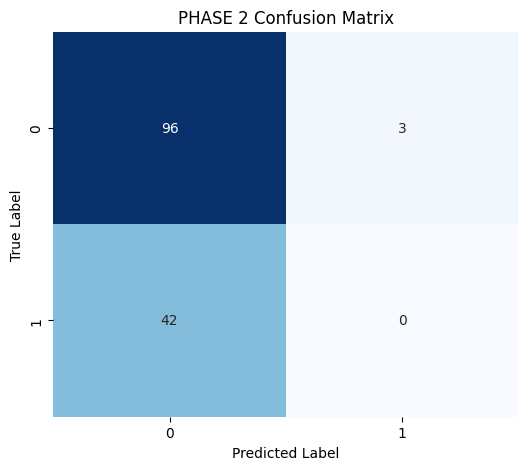


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 132)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 106)

----- Fold 1 -----
Fold ROC-AUC: 0.66

----- Fold 2 -----
Fold ROC-AUC: 0.5

----- Fold 3 -----
Fold ROC-AUC: 0.55

----- Fold 4 -----
Fold ROC-AUC: 0.625

----- Fold 5 -----
Fold ROC-AUC: 0.2

----- Fold 6 -----
Fold ROC-AUC: 0.625

----- Fold 7 -----
Fold ROC-AUC: 0.25

----- Fold 8 -----
Fold ROC-AUC: 0.75

----- Fold 9 -----
Fold ROC-AUC: 0.5

----- Fold 10 -----
Fold ROC-AUC: 0.6667

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.66   0.5    0.55   0.625  0.2    0.625  0.25   0.75   0.5    0.6667]

Mean Fold ROC-AUC:
0.5327

Overall ROC-AUC:
0.5327

Classification Report:
              precision    recall  f1-score   s

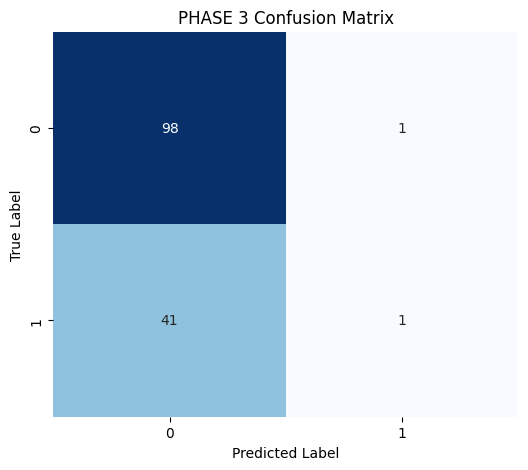


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6150
Phase 1 Precision: 0.4286
Phase 1 Recall: 0.0714
Phase 1 F1 Score: 0.1224

Phase 2 ROC-AUC: 0.5899
Phase 2 Precision: 0.0000
Phase 2 Recall: 0.0000
Phase 2 F1 Score: 0.0000

Phase 3 ROC-AUC: 0.5327
Phase 3 Precision: 0.5000
Phase 3 Recall: 0.0238
Phase 3 F1 Score: 0.0455


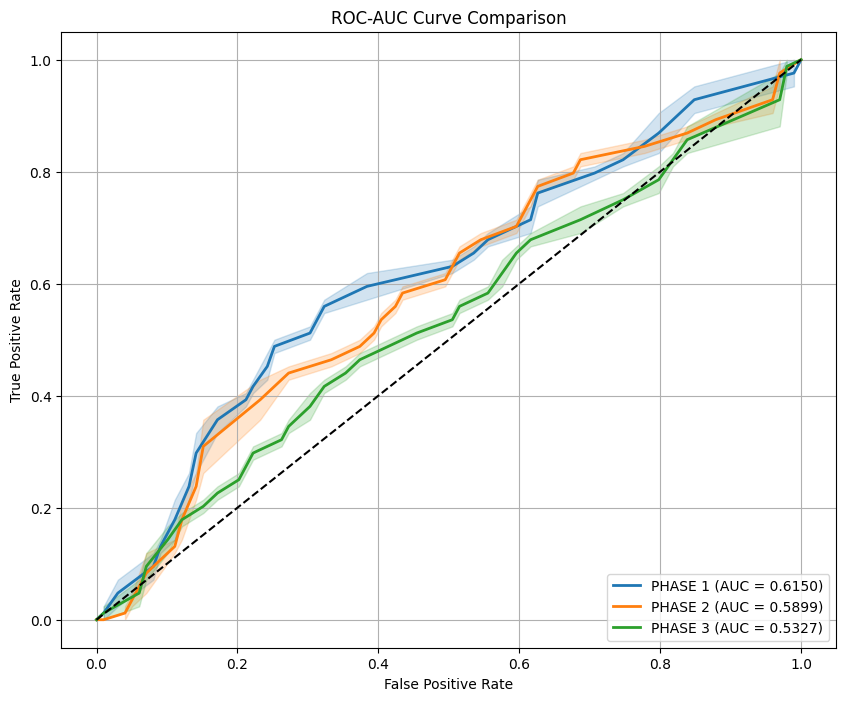

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # keep numeric only
    df_phase = df_phase.select_dtypes(
        include=["int64", "float64"]
    )

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase.drop("label", axis=1)
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    selector = VarianceThreshold(
        threshold=0.002
    )

    X = selector.fit_transform(X)

    print("Shape After Variance Threshold:", X.shape)

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # tuned svm model
        model = SVC(

            # nonlinear separation
            kernel="rbf",

            # needed for roc-auc
            probability=True,

            # handle imbalance
            class_weight="balanced",

            # stronger fitting
            C=3,

            # smoother boundary
            gamma=0.0005,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        THRESHOLD = 0.40

        y_prob = model.predict_proba(X_test)[:, 1]

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y, all_preds)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y, all_preds)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y, all_preds)

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter phase-wise data
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Logistic Regression

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 108)
Shape After SelectKBest: (141, 108)

Predicted Distribution:
[13 16]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.45      0.55        20
           1       0.31      0.56      0.40         9

    accuracy                           0.48        29
   macro avg       0.50      0.50      0.47        29
weighted avg       0.57      0.48      0.50        29

Precision Score: 0.3125
Recall S

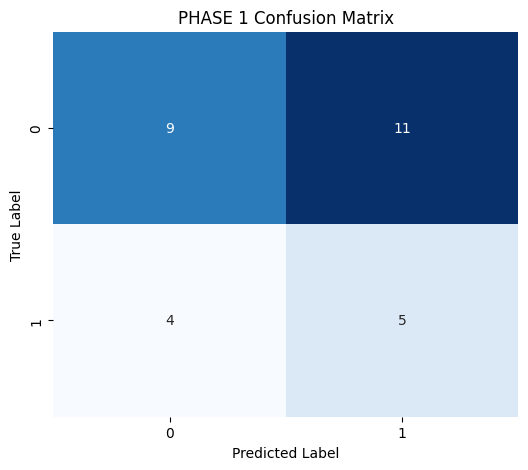


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 108)
Shape After SelectKBest: (141, 108)

Predicted Distribution:
[14 15]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.45      0.53        20
           1       0.27      0.44      0.33         9

    accuracy                           0.45        29
   macro avg       0.45      0.45      0.43        29
weighted avg       0.53      0.45      0.47        29

Precision Score: 0.2667
Recall Score: 0.4444
F1 Score: 0.3333
ROC-AUC Score: 0.5444

Confusion Matrix:
[[ 9 11]
 [ 5  4]]


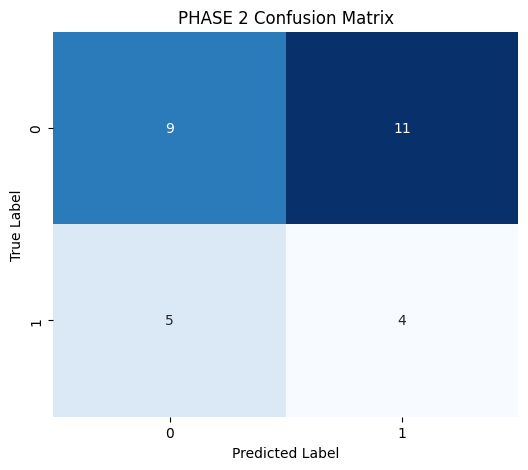


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 108)
Shape After SelectKBest: (141, 108)

Predicted Distribution:
[16 13]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        20
           1       0.23      0.33      0.27         9

    accuracy                           0.45        29
   macro avg       0.43      0.42      0.41        29
weighted avg       0.50      0.45      0.47        29

Precision Score: 0.2308
Recall Score: 0.3333
F1 Score: 0.2727
ROC-AUC Score: 0.4278

Confusion Matrix:
[[10 10]
 [ 6  3]]


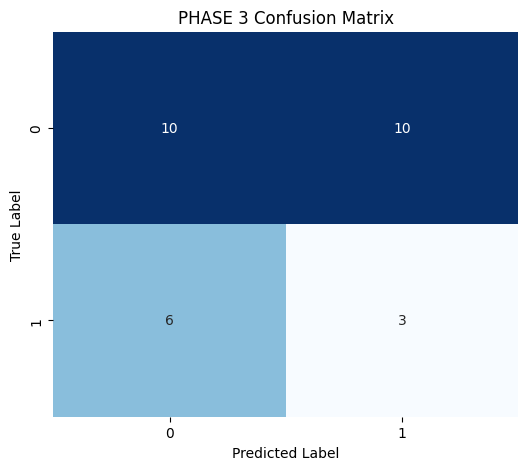


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.5333
Phase 1 Precision: 0.3125
Phase 1 Recall: 0.5556
Phase 1 F1 Score: 0.4000

Phase 2 ROC-AUC: 0.5444
Phase 2 Precision: 0.2667
Phase 2 Recall: 0.4444
Phase 2 F1 Score: 0.3333

Phase 3 ROC-AUC: 0.4278
Phase 3 Precision: 0.2308
Phase 3 Recall: 0.3333
Phase 3 F1 Score: 0.2727


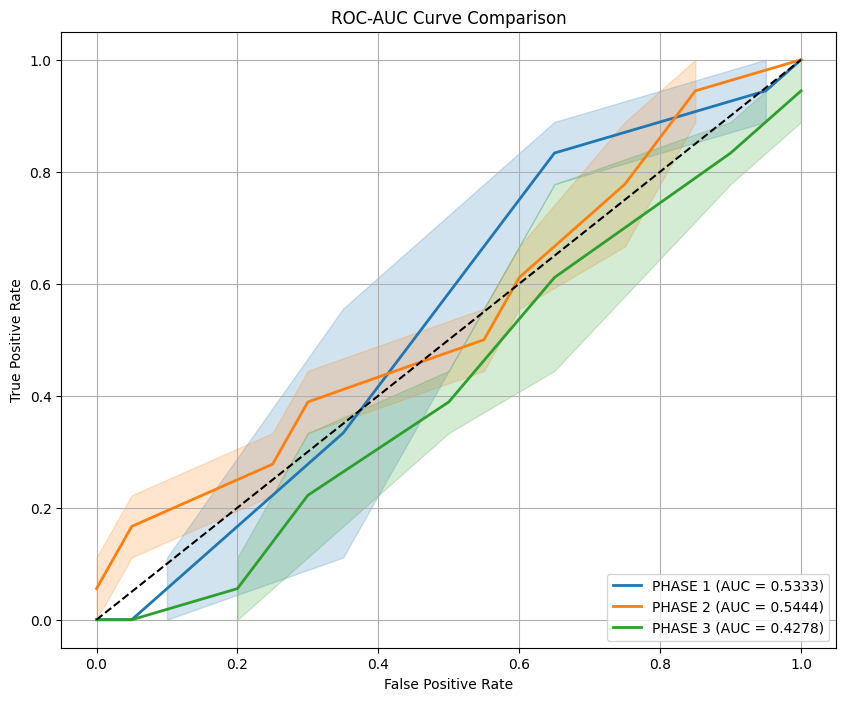

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.0005
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select best features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(120, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # feature scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # tuned logistic regression
    model = LogisticRegression(

        # stronger regularization tuning
        C=0.3,

        # handles imbalance
        class_weight="balanced",

        # better convergence
        solver="liblinear",

        # more iterations
        max_iter=1000,

        random_state=42
    )

    # train model
    model.fit(X_train, y_train)

    # predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold
    THRESHOLD = 0.35

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y_test, y_pred)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y_test, y_pred)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y_test, y_pred)

    print("F1 Score:", round(f1, 4))

    # roc-auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Logistic Regression 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 108)
Shape After SelectKBest: (141, 108)

----- Fold 1 -----
Fold ROC-AUC: 0.6556

----- Fold 2 -----
Fold ROC-AUC: 0.4938

----- Fold 3 -----
Fold ROC-AUC: 0.7812

----- Fold 4 -----
Fold ROC-AUC: 0.6938

----- Fold 5 -----
Fold ROC-AUC: 0.6082

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6556 0.4938 0.7812 0.6938 0.6082]

Mean Fold ROC-AUC:
0.6465

Overa

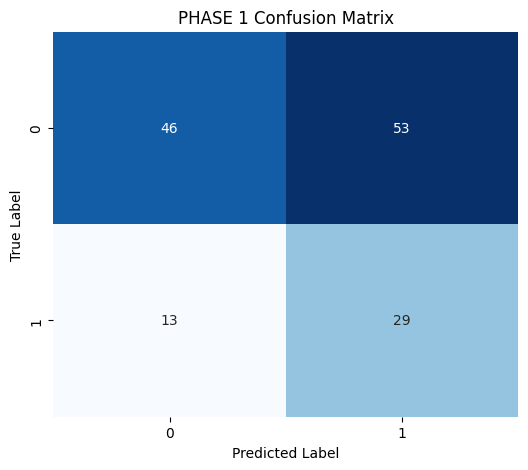


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 108)
Shape After SelectKBest: (141, 108)

----- Fold 1 -----
Fold ROC-AUC: 0.6778

----- Fold 2 -----
Fold ROC-AUC: 0.3688

----- Fold 3 -----
Fold ROC-AUC: 0.6562

----- Fold 4 -----
Fold ROC-AUC: 0.6188

----- Fold 5 -----
Fold ROC-AUC: 0.7368

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6778 0.3688 0.6562 0.6188 0.7368]

Mean Fold ROC-AUC:
0.6117

Overall ROC-AUC:
0.5926

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.51      0.61        99
           1       0.35      0.62      0.44        42

    accuracy                           0.54       141
   macro avg  

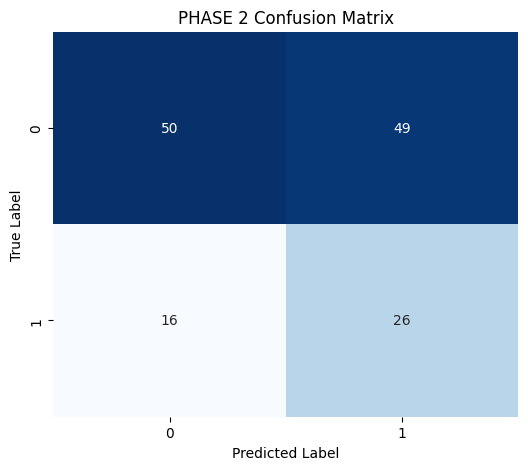


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 108)
Shape After SelectKBest: (141, 108)

----- Fold 1 -----
Fold ROC-AUC: 0.5944

----- Fold 2 -----
Fold ROC-AUC: 0.4562

----- Fold 3 -----
Fold ROC-AUC: 0.725

----- Fold 4 -----
Fold ROC-AUC: 0.6812

----- Fold 5 -----
Fold ROC-AUC: 0.5848

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5944 0.4562 0.725  0.6812 0.5848]

Mean Fold ROC-AUC:
0.6083

Overall ROC-AUC:
0.6061

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.41      0.55        99
           1       0.36      0.76      0.48        42

    accuracy                           0.52       141
   macro avg   

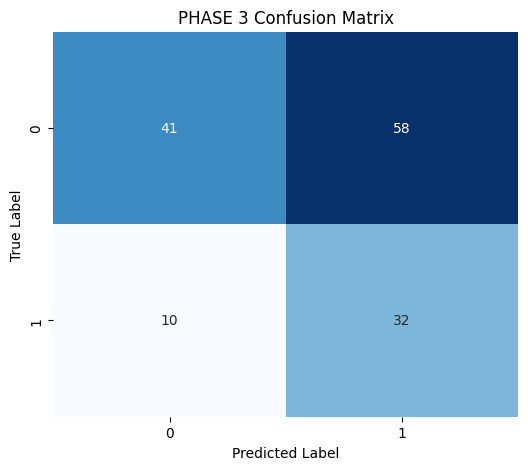


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6356
Phase 1 Precision: 0.3537
Phase 1 Recall: 0.6905
Phase 1 F1 Score: 0.4677

Phase 2 ROC-AUC: 0.5926
Phase 2 Precision: 0.3467
Phase 2 Recall: 0.6190
Phase 2 F1 Score: 0.4444

Phase 3 ROC-AUC: 0.6061
Phase 3 Precision: 0.3556
Phase 3 Recall: 0.7619
Phase 3 F1 Score: 0.4848


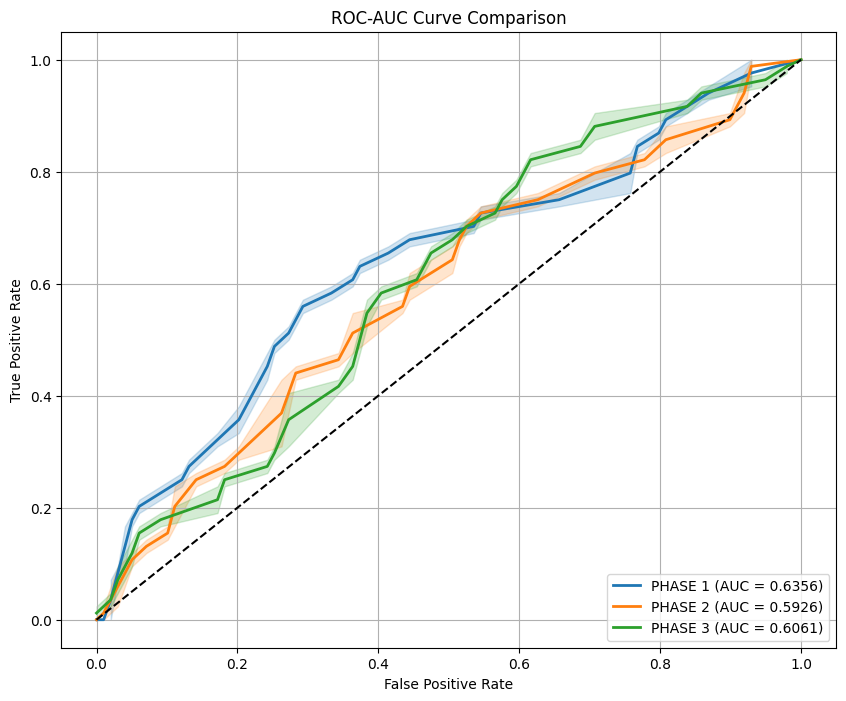

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.0005
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select best features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(120, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # logistic regression model
        model = LogisticRegression(

            # better generalization
            C=0.3,

            # handle imbalance
            class_weight="balanced",

            # stable solver
            solver="liblinear",

            # better convergence
            max_iter=1000,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y, all_preds)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y, all_preds)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y, all_preds)

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Logistic Regression 10 Folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 108)
Shape After SelectKBest: (141, 108)

----- Fold 1 -----
Fold ROC-AUC: 0.58

----- Fold 2 -----
Fold ROC-AUC: 0.6

----- Fold 3 -----
Fold ROC-AUC: 0.425

----- Fold 4 -----
Fold ROC-AUC: 0.65

----- Fold 5 -----
Fold ROC-AUC: 0.775

----- Fold 6 -----
Fold ROC-AUC: 0.9

----- Fold 7 -----
Fold ROC-AUC: 0.55

----- Fold 8 -----
Fold ROC-AUC: 0.625

----- Fold 9 -----
Fold ROC-AUC: 0.35

----- Fold 10 -----
Fold ROC-AUC: 0.5111

---------------------------------------------------

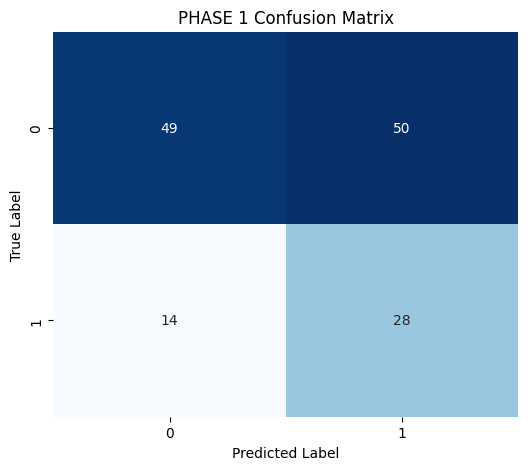


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 108)
Shape After SelectKBest: (141, 108)

----- Fold 1 -----
Fold ROC-AUC: 0.74

----- Fold 2 -----
Fold ROC-AUC: 0.55

----- Fold 3 -----
Fold ROC-AUC: 0.3

----- Fold 4 -----
Fold ROC-AUC: 0.725

----- Fold 5 -----
Fold ROC-AUC: 0.6

----- Fold 6 -----
Fold ROC-AUC: 0.7

----- Fold 7 -----
Fold ROC-AUC: 0.575

----- Fold 8 -----
Fold ROC-AUC: 0.5

----- Fold 9 -----
Fold ROC-AUC: 0.4

----- Fold 10 -----
Fold ROC-AUC: 0.8

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.74  0.55  0.3   0.725 0.6   0.7   0.575 0.5   0.4   0.8  ]

Mean Fold ROC-AUC:
0.589

Overall ROC-AUC:
0.6025

Classification Report:
              precision   

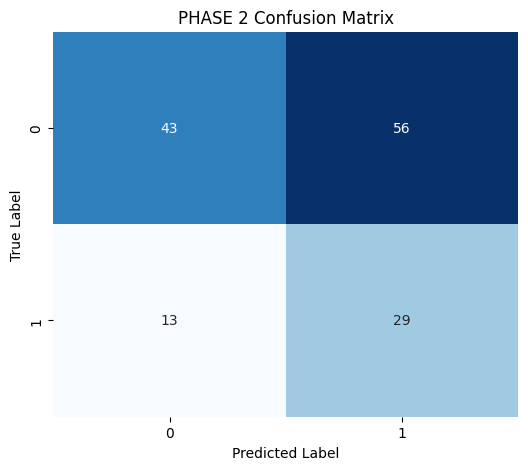


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 108)
Shape After SelectKBest: (141, 108)

----- Fold 1 -----
Fold ROC-AUC: 0.68

----- Fold 2 -----
Fold ROC-AUC: 0.475

----- Fold 3 -----
Fold ROC-AUC: 0.525

----- Fold 4 -----
Fold ROC-AUC: 0.55

----- Fold 5 -----
Fold ROC-AUC: 0.675

----- Fold 6 -----
Fold ROC-AUC: 0.675

----- Fold 7 -----
Fold ROC-AUC: 0.725

----- Fold 8 -----
Fold ROC-AUC: 0.55

----- Fold 9 -----
Fold ROC-AUC: 0.325

----- Fold 10 -----
Fold ROC-AUC: 0.6222

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.68   0.475  0.525  0.55   0.675  0.675  0.725  0.55   0.325  0.6222]

Mean Fold ROC-AUC:
0.5802

Overall ROC-AUC:
0.5936

Classification Report:
   

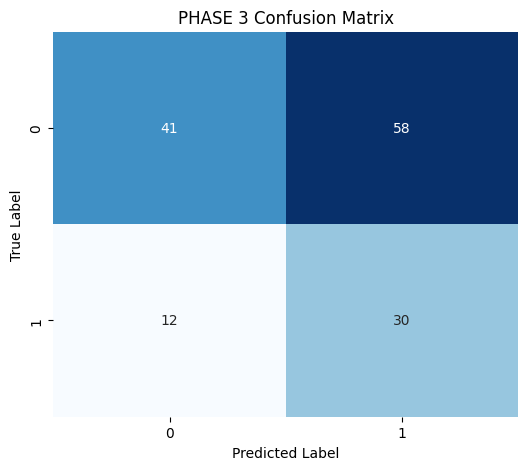


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6065
Phase 1 Precision: 0.3590
Phase 1 Recall: 0.6667
Phase 1 F1 Score: 0.4667

Phase 2 ROC-AUC: 0.6025
Phase 2 Precision: 0.3412
Phase 2 Recall: 0.6905
Phase 2 F1 Score: 0.4567

Phase 3 ROC-AUC: 0.5936
Phase 3 Precision: 0.3409
Phase 3 Recall: 0.7143
Phase 3 F1 Score: 0.4615


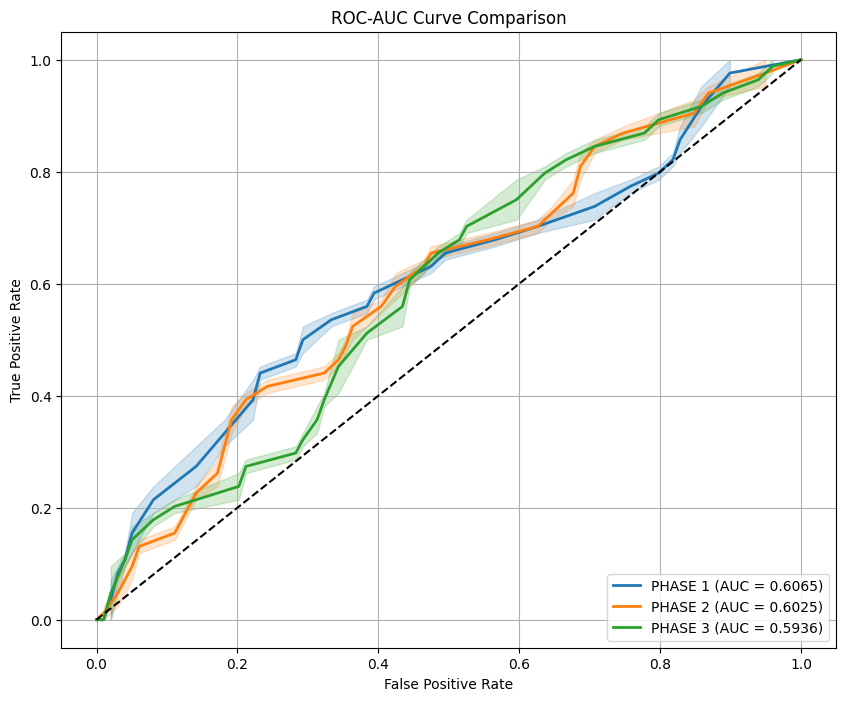

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.0005
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select best features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(120, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # logistic regression model
        model = LogisticRegression(

            # better generalization
            C=0.3,

            # handle imbalance
            class_weight="balanced",

            # stable solver
            solver="liblinear",

            # better convergence
            max_iter=1000,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y, all_preds)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y, all_preds)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y, all_preds)

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

CatBoost

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 80)
Class Weights: [1, np.float64(2.393939393939394)]

Predicted Distribution:
[15 14]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.55      0.63        20
           1       0.36      0.56      0.43         9

    accuracy                           0.55        29
   macro avg       0.55      0.55      0.53        29
weighted avg       0.62      0.55     

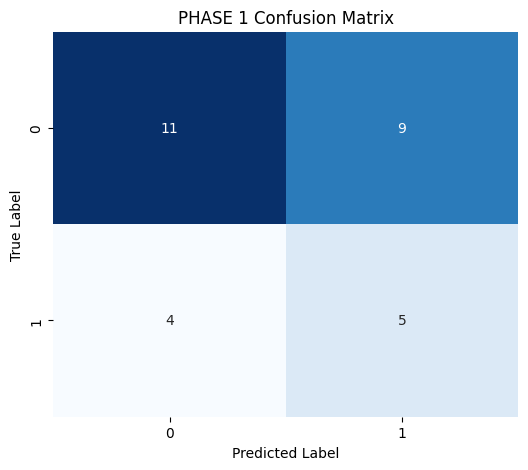


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 80)
Class Weights: [1, np.float64(2.393939393939394)]

Predicted Distribution:
[15 14]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57        20
           1       0.29      0.44      0.35         9

    accuracy                           0.48        29
   macro avg       0.48      0.47      0.46        29
weighted avg       0.55      0.48      0.50        29

Precision Score: 0.2857
Recall Score: 0.4444
F1 Score: 0.3478
ROC-AUC Score: 0.4556

Confusion Matrix:
[[10 10]
 [ 5  4]]


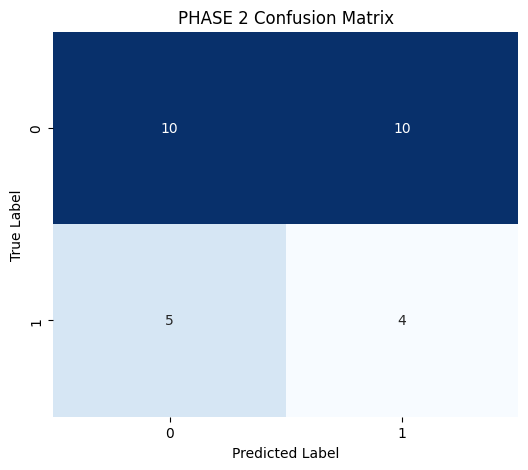


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 80)
Class Weights: [1, np.float64(2.393939393939394)]

Predicted Distribution:
[20  9]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        20
           1       0.22      0.22      0.22         9

    accuracy                           0.52        29
   macro avg       0.44      0.44      0.44        29
weighted avg       0.52      0.52      0.52        29

Precision Score: 0.2222
Recall Score: 0.2222
F1 Score: 0.2222
ROC-AUC Score: 0.3833

Confusion Matrix:
[[13  7]
 [ 7  2]]


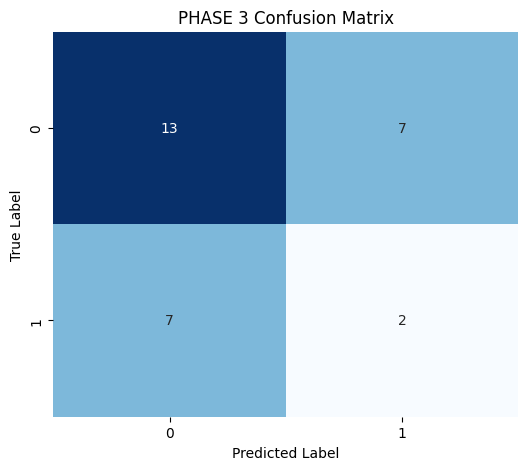


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.5056
Phase 1 Precision: 0.3571
Phase 1 Recall: 0.5556
Phase 1 F1 Score: 0.4348

Phase 2 ROC-AUC: 0.4556
Phase 2 Precision: 0.2857
Phase 2 Recall: 0.4444
Phase 2 F1 Score: 0.3478

Phase 3 ROC-AUC: 0.3833
Phase 3 Precision: 0.2222
Phase 3 Recall: 0.2222
Phase 3 F1 Score: 0.2222


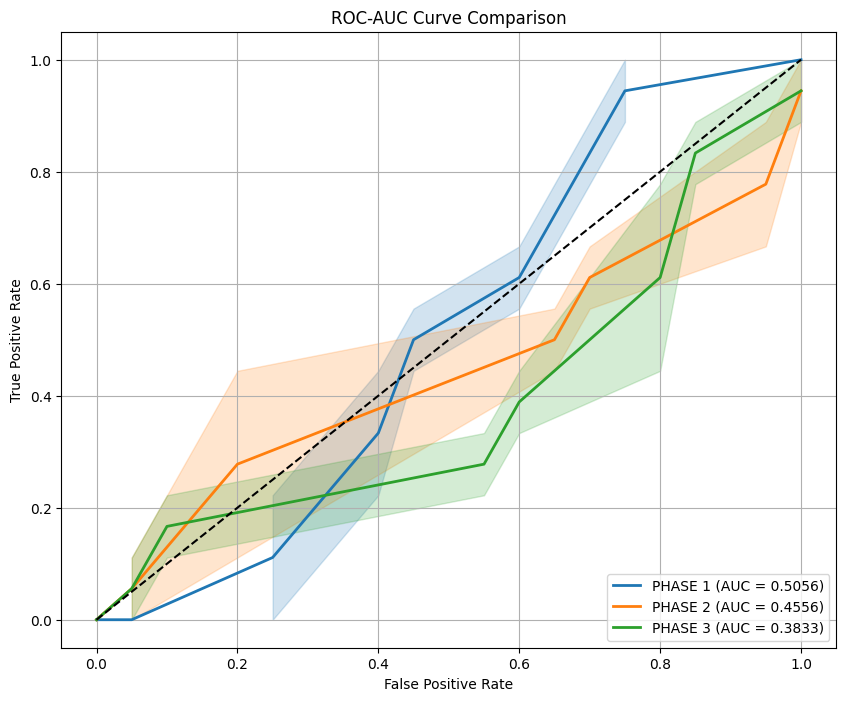

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from catboost import CatBoostClassifier

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important audio features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(80, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # handle class imbalance
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)

    class_weights = [
        1,
        neg / pos
    ]

    print("Class Weights:", class_weights)

    # balanced audio catboost
    model = CatBoostClassifier(

        # core
        loss_function="Logloss",
        eval_metric="AUC",

        # moderate boosting
        iterations=500,

        # moderate depth
        depth=5,

        # balanced learning
        learning_rate=0.025,

        # slightly stronger regularization
        l2_leaf_reg=7,

        # lower randomness
        random_strength=1,

        # better generalization
        bootstrap_type="Bernoulli",
        subsample=0.8,

        # handle imbalance
        class_weights=class_weights,

        # stable trees
        grow_policy="SymmetricTree",

        random_seed=42,

        verbose=0
    )

    # train model
    model.fit(
        X_train,
        y_train
    )

    # predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold
    THRESHOLD = 0.35

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y_test, y_pred)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y_test, y_pred)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y_test, y_pred)

    print("F1 Score:", round(f1, 4))

    # roc-auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

CatBoost 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 80)

----- Fold 1 -----
Fold ROC-AUC: 0.5389

----- Fold 2 -----
Fold ROC-AUC: 0.775

----- Fold 3 -----
Fold ROC-AUC: 0.6687

----- Fold 4 -----
Fold ROC-AUC: 0.6937

----- Fold 5 -----
Fold ROC-AUC: 0.5906

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5389 0.775  0.6688 0.6938 0.5906]

Mean Fold ROC-AUC:
0.6534

Overall

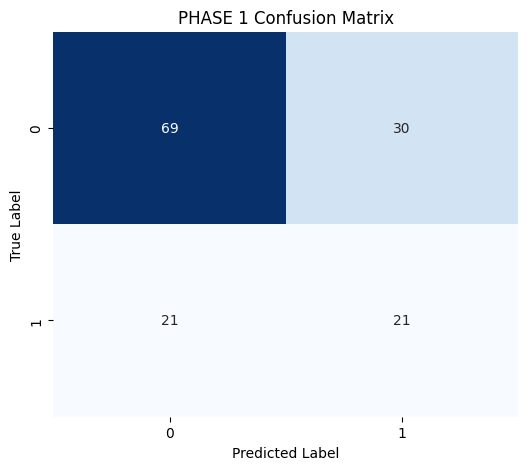


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 80)

----- Fold 1 -----
Fold ROC-AUC: 0.5389

----- Fold 2 -----
Fold ROC-AUC: 0.5125

----- Fold 3 -----
Fold ROC-AUC: 0.575

----- Fold 4 -----
Fold ROC-AUC: 0.6562

----- Fold 5 -----
Fold ROC-AUC: 0.7485

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5389 0.5125 0.575  0.6562 0.7485]

Mean Fold ROC-AUC:
0.6062

Overall ROC-AUC:
0.6013

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.67      0.71        99
           1       0.38      0.48      0.42        42

    accuracy                           0.61       141
   macro avg    

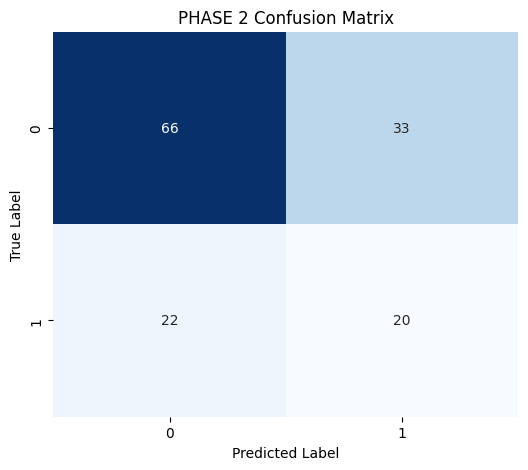


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 80)

----- Fold 1 -----
Fold ROC-AUC: 0.6333

----- Fold 2 -----
Fold ROC-AUC: 0.45

----- Fold 3 -----
Fold ROC-AUC: 0.6625

----- Fold 4 -----
Fold ROC-AUC: 0.5938

----- Fold 5 -----
Fold ROC-AUC: 0.6023

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6333 0.45   0.6625 0.5938 0.6023]

Mean Fold ROC-AUC:
0.5884

Overall ROC-AUC:
0.5847

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.71      0.74        99
           1       0.43      0.52      0.47        42

    accuracy                           0.65       141
   macro avg     

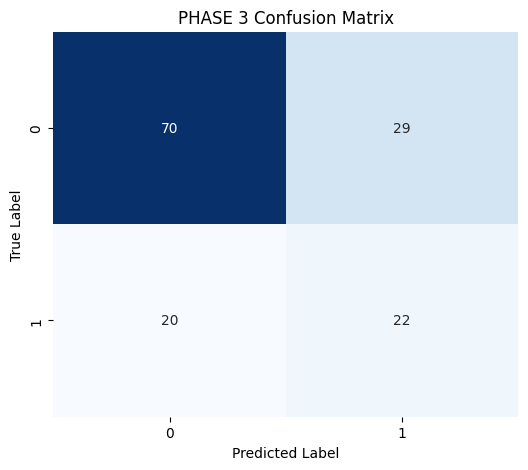


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6320
Phase 1 Precision: 0.4118
Phase 1 Recall: 0.5000
Phase 1 F1 Score: 0.4516

Phase 2 ROC-AUC: 0.6013
Phase 2 Precision: 0.3774
Phase 2 Recall: 0.4762
Phase 2 F1 Score: 0.4211

Phase 3 ROC-AUC: 0.5847
Phase 3 Precision: 0.4314
Phase 3 Recall: 0.5238
Phase 3 F1 Score: 0.4731


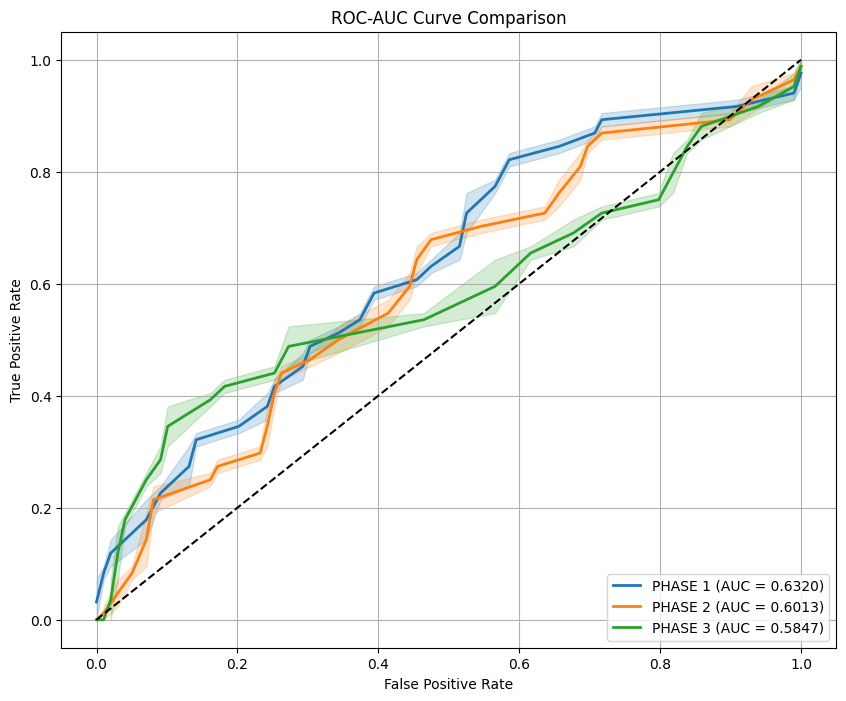

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from catboost import CatBoostClassifier

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important audio features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(80, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # handle class imbalance
        neg = np.sum(y_train == 0)
        pos = np.sum(y_train == 1)

        class_weights = [
            1,
            neg / pos
        ]

        # balanced audio catboost
        model = CatBoostClassifier(

            # core
            loss_function="Logloss",
            eval_metric="AUC",

            # moderate boosting
            iterations=500,

            # moderate depth
            depth=5,

            # balanced learning
            learning_rate=0.025,

            # slightly stronger regularization
            l2_leaf_reg=7,

            # lower randomness
            random_strength=1,

            # better generalization
            bootstrap_type="Bernoulli",
            subsample=0.8,

            # handle imbalance
            class_weights=class_weights,

            # stable trees
            grow_policy="SymmetricTree",

            random_seed=42,

            verbose=0
        )

        # train model
        model.fit(
            X_train,
            y_train
        )

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y, all_preds)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y, all_preds)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y, all_preds)

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

CatBoost 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 80)

----- Fold 1 -----
Fold ROC-AUC: 0.64

----- Fold 2 -----
Fold ROC-AUC: 0.475

----- Fold 3 -----
Fold ROC-AUC: 0.775

----- Fold 4 -----
Fold ROC-AUC: 0.625

----- Fold 5 -----
Fold ROC-AUC: 0.825

----- Fold 6 -----
Fold ROC-AUC: 0.55

----- Fold 7 -----
Fold ROC-AUC: 0.625

----- Fold 8 -----
Fold ROC-AUC: 0.7

----- Fold 9 -----
Fold ROC-AUC: 0.575

----- Fold 10 -----
Fold ROC-AUC: 0.4444

------------------------------------------------

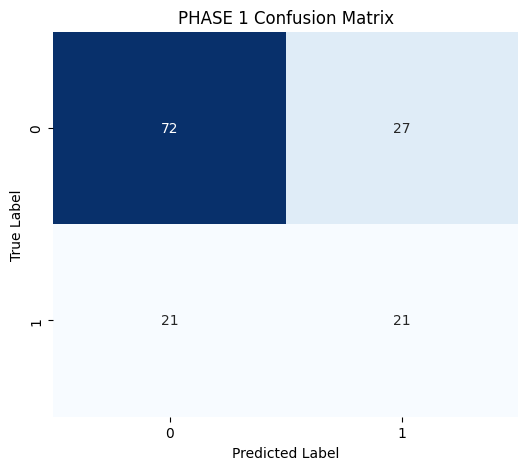


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 80)

----- Fold 1 -----
Fold ROC-AUC: 0.66

----- Fold 2 -----
Fold ROC-AUC: 0.625

----- Fold 3 -----
Fold ROC-AUC: 0.375

----- Fold 4 -----
Fold ROC-AUC: 0.725

----- Fold 5 -----
Fold ROC-AUC: 0.45

----- Fold 6 -----
Fold ROC-AUC: 0.3

----- Fold 7 -----
Fold ROC-AUC: 0.6

----- Fold 8 -----
Fold ROC-AUC: 0.775

----- Fold 9 -----
Fold ROC-AUC: 0.575

----- Fold 10 -----
Fold ROC-AUC: 0.8222

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.66   0.625  0.375  0.725  0.45   0.3    0.6    0.775  0.575  0.8222]

Mean Fold ROC-AUC:
0.5907

Overall ROC-AUC:
0.6061

Classification Report:
       

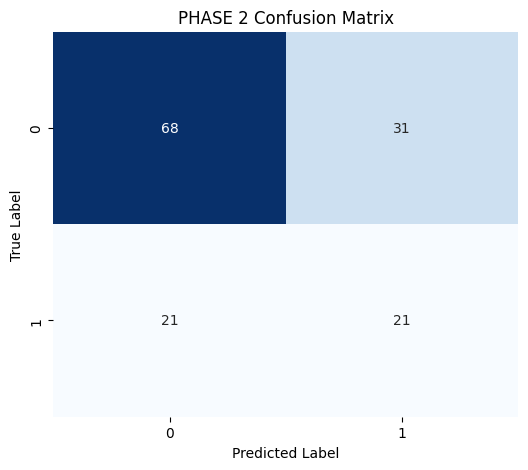


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 80)

----- Fold 1 -----
Fold ROC-AUC: 0.62

----- Fold 2 -----
Fold ROC-AUC: 0.65

----- Fold 3 -----
Fold ROC-AUC: 0.35

----- Fold 4 -----
Fold ROC-AUC: 0.825

----- Fold 5 -----
Fold ROC-AUC: 0.75

----- Fold 6 -----
Fold ROC-AUC: 0.55

----- Fold 7 -----
Fold ROC-AUC: 0.85

----- Fold 8 -----
Fold ROC-AUC: 0.525

----- Fold 9 -----
Fold ROC-AUC: 0.325

----- Fold 10 -----
Fold ROC-AUC: 0.8222

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.62   0.65   0.35   0.825  0.75   0.55   0.85   0.525  0.325  0.8222]

Mean Fold ROC-AUC:
0.6267

Overall ROC-AUC:
0.613

Classification Report:
        

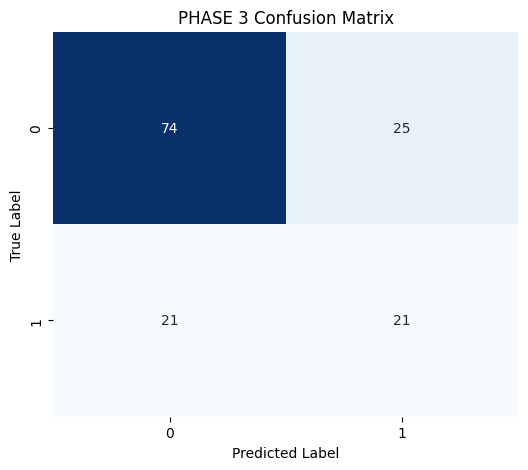


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6323
Phase 1 Precision: 0.4375
Phase 1 Recall: 0.5000
Phase 1 F1 Score: 0.4667

Phase 2 ROC-AUC: 0.6061
Phase 2 Precision: 0.4038
Phase 2 Recall: 0.5000
Phase 2 F1 Score: 0.4468

Phase 3 ROC-AUC: 0.6130
Phase 3 Precision: 0.4565
Phase 3 Recall: 0.5000
Phase 3 F1 Score: 0.4773


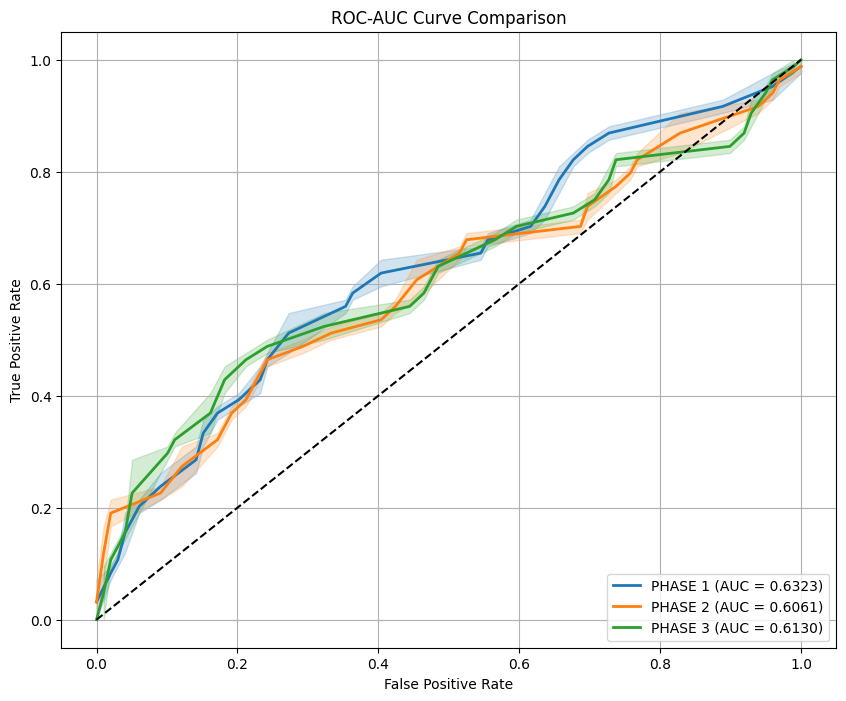

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from catboost import CatBoostClassifier

# load dataset
df = pd.read_csv("../../data/audio_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important audio features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(80, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # handle class imbalance
        neg = np.sum(y_train == 0)
        pos = np.sum(y_train == 1)

        class_weights = [
            1,
            neg / pos
        ]

        # balanced audio catboost
        model = CatBoostClassifier(

            # core
            loss_function="Logloss",
            eval_metric="AUC",

            # moderate boosting
            iterations=500,

            # moderate depth
            depth=5,

            # balanced learning
            learning_rate=0.025,

            # slightly stronger regularization
            l2_leaf_reg=7,

            # lower randomness
            random_strength=1,

            # better generalization
            bootstrap_type="Bernoulli",
            subsample=0.8,

            # handle imbalance
            class_weights=class_weights,

            # stable trees
            grow_policy="SymmetricTree",

            random_seed=42,

            verbose=0
        )

        # train model
        model.fit(
            X_train,
            y_train
        )

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(y, all_preds)

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(y, all_preds)

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(y, all_preds)

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

FNN

------------------------------------------------------------
device info
------------------------------------------------------------
Using Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU

Dataset Shape: (423, 134)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 131

------------------------------------------------------------
training for PHASE 1
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 70)

Starting Training...

Epoch [1/40] Loss: 1.0426 AUC: 0.4389
Epoch [2/40] Loss: 0.9956 AUC: 0.4500
Epoch [3/40] Loss: 1.0603 AUC: 0.4556
Epoch [4/40] Loss: 1.0521 AUC: 0.4944
Epoch [5/40] Loss: 1.0386 AUC: 0.4722
Epoch [6/40] Loss: 0.9942 AUC: 0.4833
Epoch [7/40] Loss: 1.0160 AUC: 0.4722
Epoch [8/40] Loss: 0.9827 AUC: 0.4889
Epoch [9/40] Loss: 0.9745 AUC: 0.4611
Epoch [10/40] Loss: 1.0360 AUC

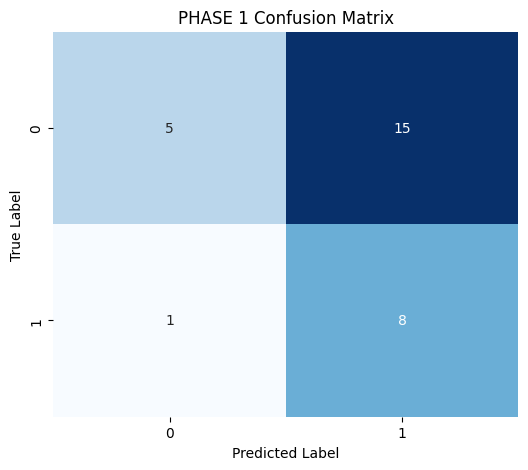


------------------------------------------------------------
training for PHASE 2
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 70)

Starting Training...

Epoch [1/40] Loss: 0.9749 AUC: 0.4667
Epoch [2/40] Loss: 1.0203 AUC: 0.4278
Epoch [3/40] Loss: 1.0205 AUC: 0.4167
Epoch [4/40] Loss: 0.9752 AUC: 0.4333
Epoch [5/40] Loss: 0.9806 AUC: 0.4444
Epoch [6/40] Loss: 1.0072 AUC: 0.4500
Epoch [7/40] Loss: 0.9128 AUC: 0.4167
Epoch [8/40] Loss: 0.9847 AUC: 0.4556
Epoch [9/40] Loss: 1.0033 AUC: 0.4389
Epoch [10/40] Loss: 0.9646 AUC: 0.4278
Epoch [11/40] Loss: 0.9888 AUC: 0.4500
Epoch [12/40] Loss: 0.9718 AUC: 0.4500
Epoch [13/40] Loss: 1.0002 AUC: 0.4500
Epoch [14/40] Loss: 0.9840 AUC: 0.4556
Epoch [15/40] Loss: 0.9400 AUC: 0.4111
Epoch [16/40] Loss: 1.0069 AUC: 0.4556
Epoch [17/40] Loss: 0.9782 AUC: 0.4333
Epoch [18/40] Loss: 0.9862 AUC: 0.4111
Epoch 

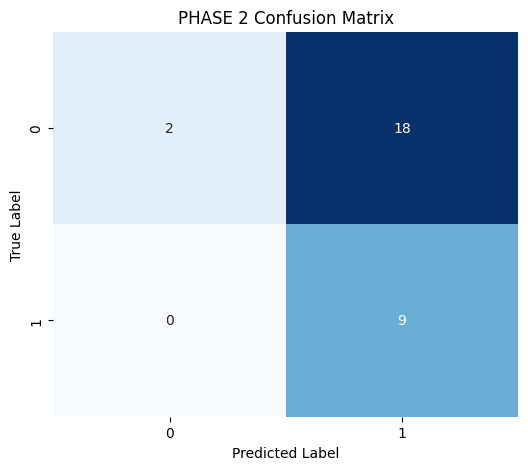


------------------------------------------------------------
training for PHASE 3
------------------------------------------------------------
Original Shape: (141, 131)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 127)
Shape After SelectKBest: (141, 70)

Starting Training...

Epoch [1/40] Loss: 1.0336 AUC: 0.4500
Epoch [2/40] Loss: 1.0169 AUC: 0.4278
Epoch [3/40] Loss: 0.9898 AUC: 0.4556
Epoch [4/40] Loss: 0.9559 AUC: 0.4444
Epoch [5/40] Loss: 0.9605 AUC: 0.4611
Epoch [6/40] Loss: 0.9605 AUC: 0.4500
Epoch [7/40] Loss: 0.9840 AUC: 0.4556
Epoch [8/40] Loss: 0.9731 AUC: 0.4222
Epoch [9/40] Loss: 0.9296 AUC: 0.4444
Epoch [10/40] Loss: 0.9434 AUC: 0.4389
Epoch [11/40] Loss: 0.9599 AUC: 0.4389
Epoch [12/40] Loss: 0.9927 AUC: 0.4333
Epoch [13/40] Loss: 0.9743 AUC: 0.4389
Epoch [14/40] Loss: 0.9620 AUC: 0.4167
Epoch [15/40] Loss: 0.9940 AUC: 0.4333
Epoch [16/40] Loss: 0.9769 AUC: 0.4611
Epoch [17/40] Loss: 1.0393 AUC: 0.4167
Epoch [18/40] Loss: 0.9734 AUC: 0.4444
Epoch 

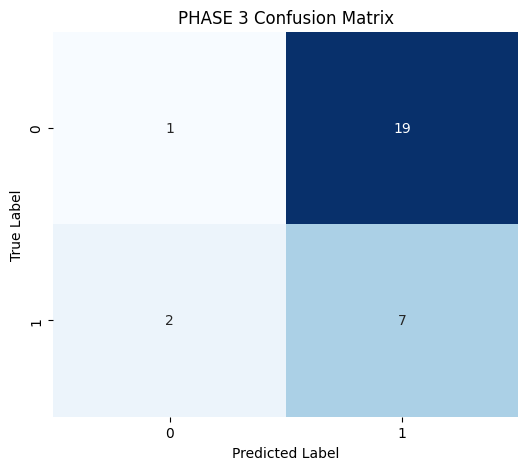


------------------------------------------------------------
final roc-auc scores
------------------------------------------------------------
Phase 1 ROC-AUC: 0.5222
Phase 1 Precision: 0.3478
Phase 1 Recall: 0.8889
Phase 1 F1 Score: 0.5000

Phase 2 ROC-AUC: 0.4778
Phase 2 Precision: 0.3333
Phase 2 Recall: 1.0000
Phase 2 F1 Score: 0.5000

Phase 3 ROC-AUC: 0.4611
Phase 3 Precision: 0.2692
Phase 3 Recall: 0.7778
Phase 3 F1 Score: 0.4000


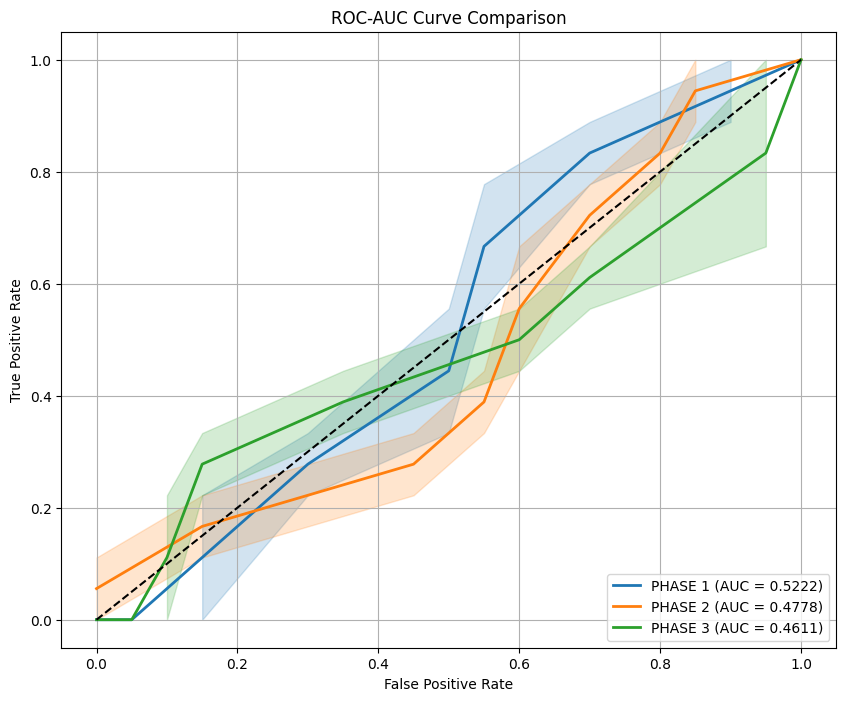

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# gpu setup

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("-" * 60)
print("device info")
print("-" * 60)

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# load dataset

df = pd.read_csv("../../data/audio_features_phasewise.csv")

df["phase"] = (
    df["phase"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("\nDataset Shape:", df.shape)

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns

remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data

roc_data = {}

# custom dataset

class DepressionDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

# audio phase-1 optimized fnn

class DepressionDNN(nn.Module):

    def __init__(self, input_dim):

        super(DepressionDNN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.50),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.45),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze()

# train function

def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"training for {phase_name}")
    print("-" * 60)

    df_phase = df_phase.dropna()

    # features & labels

    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)

    print("Class Distribution:", np.bincount(y))

    # remove low variance features

    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select important features

    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(70, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # feature scaling

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    # datasets

    train_dataset = DepressionDataset(
        X_train,
        y_train
    )

    test_dataset = DepressionDataset(
        X_test,
        y_test
    )

    # dataloaders

    train_loader = DataLoader(
        train_dataset,
        batch_size=8,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=8,
        shuffle=False
    )

    # model

    model = DepressionDNN(
        input_dim=X_train.shape[1]
    ).to(device)

    # class weighting

    class_counts = np.bincount(y_train)

    pos_weight = torch.tensor(
        class_counts[0] / class_counts[1],
        dtype=torch.float32
    ).to(device)

    # loss function

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    # optimizer

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.00008,
        weight_decay=2e-3
    )

    # scheduler

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=40
    )

    # training

    EPOCHS = 40

    best_auc = 0

    best_probs = None

    print("\nStarting Training...\n")

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)

            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            total_loss += loss.item()

        scheduler.step()

        avg_loss = total_loss / len(train_loader)

        # validation

        model.eval()

        val_probs = []

        with torch.no_grad():

            for X_batch, _ in test_loader:

                X_batch = X_batch.to(device)

                outputs = model(X_batch)

                probs = torch.sigmoid(outputs)

                probs = probs.cpu().numpy()

                val_probs.extend(probs)

        val_auc = roc_auc_score(
            y_test,
            val_probs
        )

        if val_auc > best_auc:

            best_auc = val_auc

            best_probs = val_probs.copy()

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Loss: {avg_loss:.4f} "
            f"AUC: {val_auc:.4f}"
        )

    # final evaluation

    final_probs = np.array(best_probs)

    y_pred = (final_probs > 0.42).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score

    precision = precision_score(
        y_test,
        y_pred
    )

    print("Precision Score:", round(precision, 4))

    # recall score

    recall = recall_score(
        y_test,
        y_pred
    )

    print("Recall Score:", round(recall, 4))

    # f1 score

    f1 = f1_score(
        y_test,
        y_pred
    )

    print("F1 Score:", round(f1, 4))

    # roc auc

    final_auc = roc_auc_score(
        y_test,
        final_probs
    )

    print("Best ROC-AUC:", round(final_auc, 4))

    # confusion matrix

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

    # roc curve values

    fpr, tpr, _ = roc_curve(
        y_test,
        final_probs
    )

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": final_auc
    }

    return final_auc, precision, recall, f1

# phase-wise data

df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models

roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final results

print("\n" + "-" * 60)
print("final roc-auc scores")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve

plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()